# Lending Anomaly Discovery using Statistical & Structural Outlier Detection

Fase 4: Anomaly and Outlier Detection

Pada fase ini saya menggali record yang menyimpang jauh dari perilaku mayoritas populasi,
lalu menentukan apakah tiap penyimpangan merupakan kesalahan data, kasus langka yang tetap
sah, atau sinyal risiko yang layak dieskalasi. Saya menjalankan pipeline penuh: memuat data
bersih dari Fase 1, menerapkan tiga metode deteksi yang saling melengkapi (IQR, Z-score, dan
Isolation Forest), membandingkan hasilnya secara sistematis, lalu menyilangkannya dengan
outlier klaster (noise DBSCAN) dari Fase 2 agar temuan berpijak pada bukti berlapis.

Saya memproses dua dataset agar bisa melakukan perbandingan lintas domain:
- Accepted loans: fokus utama, memuat outcome pinjaman (loan_status).
- Rejected loans: dataset komparatif untuk memahami anomali pada pengajuan yang ditolak.

Saya sengaja menghubungkan setiap anomali kembali ke konteks bisnis perbankan, karena tujuan
fase ini bukan sekadar menandai titik ekstrem, melainkan menjelaskan apa arti tiap titik itu
bagi bank dan tindakan apa yang sebaiknya diambil.

# 1. Setup & Konfigurasi Path

Saya mengimpor seluruh library yang saya butuhkan dan menetapkan path data. Default path
mengikuti struktur pipeline Fase 1-2 yang sudah saya susun.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42
print('Library berhasil diimport')

Library berhasil diimport


Saya menetapkan lokasi dua CSV hasil pembersihan Fase 1 dan dua file JSON berisi noise
DBSCAN Fase 2. Saya juga menyiapkan folder output agar seluruh gambar dan laporan anomali
tersimpan rapi untuk dipakai kembali di Fase 5.

In [2]:
# --- Path lokal (mengikuti struktur pipeline Fase 1-2) ---
PATH_ACC   = '../Datasets/Cleaning/Phase 2/clean_accepted_loans.csv'
PATH_REJ   = '../Datasets/Cleaning/Phase 2/clean_rejected_loans.csv'
PATH_DB_ACC = '../Phase 2 Clustering/dbscan_outliers_accepted.json'
PATH_DB_REJ = '../Phase 2 Clustering/dbscan_outliers_rejected.json'
PATH_CLUSTER_PROF = '../Phase 2 Clustering/Results/cluster_profiles.csv'  # profil klaster Fase 2 (agregat)
PATH_CLUSTER_LBL  = '../Phase 2 Clustering/Results/cluster_labels_accepted.parquet'  # label per-record Fase 2
PATH_CLUSTER_META = '../Phase 2 Clustering/Results/cluster_labels_meta_accepted.json'  # meta (klaster Highest-Risk)
PATH_RAW_COUNTS   = '../Datasets/Cleaning/Phase 2/raw_counts_accepted.parquet'  # nilai mentah count (pre-scaling) dari Fase 1
PATH_ISSUE_YEAR   = '../Datasets/Cleaning/Phase 2/issue_year_accepted.parquet'  # tahun terbit accepted (Fase 1)

# Folder output
import os
os.makedirs('Results', exist_ok=True)
print('Path dikonfigurasi.')

Path dikonfigurasi.


# 2. Memuat Data Bersih & Noise DBSCAN Fase 2

Saya memuat dua hal sekaligus. Pertama, dataset bersih hasil Fase 1 yang fiturnya sudah
ter-scale, sehingga siap saya proses tanpa transformasi tambahan. Kedua, daftar
noise_global_index dari DBSCAN Fase 2, yaitu record yang di fase sebelumnya sudah
teridentifikasi sebagai titik noise (tidak masuk klaster padat mana pun). Daftar inilah yang
nanti saya jadikan jembatan cross-referencing antara temuan Fase 4 dan temuan Fase 2.

In [3]:
# --- Dataset bersih ---
df_acc = pd.read_csv(PATH_ACC)
df_rej = pd.read_csv(PATH_REJ)
print(f'Accepted : {df_acc.shape[0]:,} baris x {df_acc.shape[1]} kolom')
print(f'Rejected : {df_rej.shape[0]:,} baris x {df_rej.shape[1]} kolom')

# --- Noise DBSCAN dari Fase 2 ---
with open(PATH_DB_ACC) as f: db_acc = json.load(f)
with open(PATH_DB_REJ) as f: db_rej = json.load(f)

noise_idx_acc = set(db_acc['noise_global_index'])
noise_idx_rej = set(db_rej['noise_global_index'])
print(f"\nDBSCAN Accepted : eps={db_acc['eps']:.3f}, {db_acc['n_noise']} noise "
      f"(dari sampel {db_acc['sample_size']:,}, {db_acc['pct_noise']}%)")
print(f"DBSCAN Rejected : eps={db_rej['eps']:.3f}, {db_rej['n_noise']} noise "
      f"(dari sampel {db_rej['sample_size']:,}, {db_rej['pct_noise']}%)")

Accepted : 1,348,099 baris x 15 kolom
Rejected : 27,490,787 baris x 8 kolom

DBSCAN Accepted : eps=2.920, 59 noise (dari sampel 5,000, 1.18%)
DBSCAN Rejected : eps=0.437, 171 noise (dari sampel 5,000, 3.42%)


### 2a. Dimensi Waktu untuk Filter Temporal (Fase 5)

Menambahkan kolom year ke kedua dataset agar dashboard dapat memfilter anomali per tahun
(2007 sampai 2018) dan menampilkan tren tipologi antar periode kebijakan kredit Lending Club.

- Accepted: issue_d_year dibuang saat feature selection Fase 1, jadi dimuat kembali dari
  issue_year_accepted.parquet lewat kunci row_pos (posisi baris pada CSV asal). Pola ini
  sama dengan yang dipakai raw_counts_accepted dan cluster_labels_accepted.
- Rejected: Application Date masih tersimpan utuh di clean_rejected_loans.csv,
  sehingga tahunnya cukup diekstrak langsung.

In [4]:
# --- Lampirkan kolom 'year' ke df_acc dan df_rej untuk filter temporal Fase 5 ---
# Bila sumber tahun tidak tersedia, notebook tetap berjalan (year = NaN) dan dashboard
# otomatis menyembunyikan filter tahun.

# (a) ACCEPTED: gabungkan lewat row_pos. df_acc dibaca tanpa dropna, jadi posisi barisnya
#     identik dengan urutan baris saat clean_accepted_loans.csv ditulis di Fase 1.
df_acc['year'] = np.nan
try:
    try:
        _yr = pd.read_parquet(PATH_ISSUE_YEAR)
    except Exception:
        _yr = pd.read_csv(PATH_ISSUE_YEAR.replace('.parquet', '.csv'))

    _map = dict(zip(_yr['row_pos'].astype('int64'), _yr['issue_year']))
    df_acc['year'] = pd.Series([_map.get(i, np.nan) for i in range(len(df_acc))],
                               index=df_acc.index)
    _matched = int(df_acc['year'].notna().sum())
    print(f"Accepted: tahun tercocokkan untuk {_matched:,}/{len(df_acc):,} baris "
          f"({_matched/len(df_acc)*100:.1f}%)")
    if _matched:
        print(f"  Rentang: {int(df_acc['year'].min())}-{int(df_acc['year'].max())}")
except FileNotFoundError:
    print("issue_year_accepted belum ada. Jalankan ulang Fase 1 (sel penyimpanan) "
          "untuk mengekspornya, lalu jalankan sel ini lagi.")
except Exception as e:
    print(f"Accepted: gagal melampirkan tahun ({e}); kolom year dibiarkan kosong.")

# (b) REJECTED: 'Application Date' masih ada di CSV bersih, tinggal diambil tahunnya.
df_rej['year'] = np.nan
if 'Application Date' in df_rej.columns:
    _d = pd.to_datetime(df_rej['Application Date'], errors='coerce')
    df_rej['year'] = _d.dt.year
    _m = int(df_rej['year'].notna().sum())
    print(f"\nRejected: tahun diekstrak untuk {_m:,}/{len(df_rej):,} baris "
          f"({_m/len(df_rej)*100:.1f}%)")
    if _m:
        print(f"  Rentang: {int(df_rej['year'].min())}-{int(df_rej['year'].max())}")
else:
    print("\nRejected: kolom 'Application Date' tidak ditemukan; year dibiarkan kosong.")

Accepted: tahun tercocokkan untuk 1,348,099/1,348,099 baris (100.0%)
  Rentang: 2007-2018

Rejected: tahun diekstrak untuk 27,490,787/27,490,787 baris (100.0%)
  Rentang: 2007-2018


Perlu saya jelaskan soal indexing. Nilai pada noise_global_index adalah posisi record
pada dataset penuh, bukan index sampel. Karena notebook clustering saya memuat CSV yang sama
lalu (untuk rejected) melakukan reset index, saya memperlakukan angka ini sebagai posisi
baris (iloc) pada dataset yang saya muat di sini. Sel berikutnya saya rancang untuk
memvalidasi bahwa setiap index masih berada dalam rentang, dan melaporkan secara transparan
bila ada yang di luar rentang.

Verifikasi keselarasan index

Saya sudah mengecek angkanya: index global maksimum adalah 1.345.315 pada accepted dan
27.289.535 pada rejected, sedangkan dataset bersih saya berukuran sekitar 1.348.099 baris
(accepted) dan 27.490.787 baris (rejected). Dengan begitu seluruh index masih dalam rentang
dan cross-referencing akan berjalan.

Satu catatan kejujuran metodologis yang saya rasa penting: pipeline accepted membuang baris
berstatus Current/Late, sehingga posisi baris bisa sedikit bergeser relatif terhadap index
global saat DBSCAN dijalankan. Bila DBSCAN saya jalankan pada urutan baris yang identik
dengan CSV ini, pencocokan posisi sudah tepat. Untuk berjaga-jaga, saya menyediakan dua mode
pencocokan: mode posisi baris sebagai default, dan mode berbasis kolom identifier unik bila
saya menyimpan kolom seperti id saat clustering, yang membuat pencocokan sepenuhnya kebal
terhadap pergeseran baris.

In [5]:
# --- Mode pencocokan index DBSCAN ---
MODE = 'iloc'      # 'iloc' = cocokkan sebagai posisi baris (default)
                   # 'id'   = cocokkan lewat kolom identifier unik (paling robust)
ID_COL = None      # contoh: id. Diisi bila MODE=id dan kolom tersedia di CSV

def resolve_noise_positions(df, noise_global, name):
    # Kembalikan set POSISI baris (untuk iloc) yang berkorespondensi ke noise DBSCAN.
    if MODE == 'id' and ID_COL and ID_COL in df.columns:
        # noise_global diasumsikan berisi nilai ID, bukan posisi
        matched = df.index[df[ID_COL].isin(noise_global)].tolist()
        pos = [df.index.get_loc(i) for i in matched]
        print(f'[{name}] MODE=id: {len(pos)}/{len(noise_global)} noise tercocokkan via {ID_COL}')
        return set(pos)
    # MODE iloc
    n = len(df)
    pos = {i for i in noise_global if 0 <= i < n}
    invalid = set(noise_global) - pos
    print(f'[{name}] MODE=iloc: {len(pos)}/{len(noise_global)} index dalam rentang [0,{n:,})')
    if invalid:
        print(f'    -> {len(invalid)} di luar rentang (dilewati): {sorted(invalid)[:5]}...')
    return pos

noise_pos_acc = resolve_noise_positions(df_acc, db_acc['noise_global_index'], 'Accepted')
noise_pos_rej = resolve_noise_positions(df_rej, db_rej['noise_global_index'], 'Rejected')

[Accepted] MODE=iloc: 59/59 index dalam rentang [0,1,348,099)
[Rejected] MODE=iloc: 171/171 index dalam rentang [0,27,490,787)


# 3. Pemilihan Fitur untuk Deteksi Anomali

Saya menjalankan deteksi anomali hanya pada fitur numerik kontinu yang bermakna secara
finansial. Saya mengecualikan kolom target (loan_status_binary) supaya deteksi tidak
terbias oleh label hasil, dan membuang kolom dummy biner agar metode statistik seperti IQR
dan Z-score bekerja pada besaran yang memang kontinu. Untuk rejected, saya memakai tiga fitur
inti yang juga saya pakai pada clustering Fase 2, agar kedua fase konsisten.

In [6]:
# --- Accepted: pilih fitur numerik kontinu (bukan target, bukan dummy biner) ---
exclude_acc = {'loan_status_binary', 'loan_status'}
num_acc = [c for c in df_acc.select_dtypes(include='number').columns
           if c not in exclude_acc and df_acc[c].nunique() > 10]
print('Fitur anomali (Accepted):')
for c in num_acc: print(f'  - {c}')

# --- Rejected: tiga fitur inti yang dipakai clustering Fase 2 ---
num_rej = [c for c in ['Amount Requested', 'Debt-To-Income Ratio', 'Employment Length']
           if c in df_rej.columns]
print('\nFitur anomali (Rejected):')
for c in num_rej: print(f'  - {c}')

Fitur anomali (Accepted):
  - int_rate
  - fico_range_low
  - installment
  - acc_open_past_24mths
  - num_tl_op_past_12m
  - year

Fitur anomali (Rejected):
  - Amount Requested
  - Debt-To-Income Ratio
  - Employment Length


# 4. Metode Pertama: IQR (Interquartile Range)

Metode pertama yang saya terapkan adalah aturan Tukey berbasis IQR: sebuah nilai saya anggap
outlier bila berada di luar rentang Q1 dikurangi 1.5 IQR atau Q3 ditambah 1.5 IQR. Saya
menghitungnya per fitur, lalu menjumlahkan berapa banyak fitur yang dilanggar tiap record.
Pendekatan ini sederhana dan mudah dijelaskan ke audiens non-teknis, sehingga cocok sebagai
lapis pertama penyaringan. Saya memakai IQR yang sama seperti yang saya gunakan pada tahap
pembersihan di Fase 1, sehingga logikanya konsisten sepanjang proyek.

In [7]:
def iqr_flags(df, cols):
    # Kembalikan DataFrame boolean (baris x fitur): True bila nilai outlier IQR.
    flags = pd.DataFrame(index=df.index)
    bounds = {}
    for c in cols:
        s = df[c]
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        flags[c] = (s < lo) | (s > hi)
        bounds[c] = (lo, hi)
    return flags, bounds

iqr_flags_acc, iqr_bounds_acc = iqr_flags(df_acc, num_acc)
df_acc['iqr_n_violations'] = iqr_flags_acc.sum(axis=1)
df_acc['is_outlier_iqr'] = df_acc['iqr_n_violations'] > 0

print('IQR, ringkasan pelanggaran per fitur (Accepted):')
summary_iqr = pd.DataFrame({
    'n_outlier': iqr_flags_acc.sum(),
    'pct_outlier': (iqr_flags_acc.mean()*100).round(2)
}).sort_values('n_outlier', ascending=False)
print(summary_iqr)
print(f"\nTotal record dengan >=1 pelanggaran IQR: "
      f"{df_acc['is_outlier_iqr'].sum():,} ({df_acc['is_outlier_iqr'].mean()*100:.2f}%)")

IQR, ringkasan pelanggaran per fitur (Accepted):
                      n_outlier  pct_outlier
num_tl_op_past_12m        63825        4.730
fico_range_low            46520        3.450
installment               42191        3.130
acc_open_past_24mths      30213        2.240
int_rate                  24981        1.850
year                      20814        1.540

Total record dengan >=1 pelanggaran IQR: 196,261 (14.56%)


In [8]:
# Rejected: proses sama
iqr_flags_rej, iqr_bounds_rej = iqr_flags(df_rej, num_rej)
df_rej['iqr_n_violations'] = iqr_flags_rej.sum(axis=1)
df_rej['is_outlier_iqr'] = df_rej['iqr_n_violations'] > 0
print('IQR, ringkasan pelanggaran per fitur (Rejected):')
print(pd.DataFrame({
    'n_outlier': iqr_flags_rej.sum(),
    'pct_outlier': (iqr_flags_rej.mean()*100).round(2)
}).sort_values('n_outlier', ascending=False))
print(f"\nTotal record dengan >=1 pelanggaran IQR: "
      f"{df_rej['is_outlier_iqr'].sum():,} ({df_rej['is_outlier_iqr'].mean()*100:.2f}%)")

IQR, ringkasan pelanggaran per fitur (Rejected):
                      n_outlier  pct_outlier
Employment Length       3699190       13.460
Debt-To-Income Ratio    2367697        8.610
Amount Requested         171056        0.620

Total record dengan >=1 pelanggaran IQR: 6,068,188 (22.07%)


# 5. Metode Kedua: Z-Score

Metode kedua yang saya terapkan adalah Z-score: sebuah nilai saya tandai anomali bila jarak
dari rata-rata melebihi tiga standar deviasi (|z| > 3). Saya menghitung ulang z secara
eksplisit di sini agar metode tetap sah dan mudah diperiksa, meski data sudah ter-scale
dari Fase 1. Z-score melengkapi IQR: keduanya univariat, tetapi Z-score lebih sensitif pada
ekor distribusi yang jauh, sehingga saya bisa membandingkan seberapa konsisten kedua metode
statistik ini menandai record yang sama.

In [9]:
Z_THRESH = 3.0

def zscore_flags(df, cols, thresh=Z_THRESH):
    z = np.abs(stats.zscore(df[cols], nan_policy='omit'))
    zf = pd.DataFrame(z, index=df.index, columns=cols) > thresh
    return zf

zf_acc = zscore_flags(df_acc, num_acc)
df_acc['z_n_violations'] = zf_acc.sum(axis=1)
df_acc['is_outlier_z'] = df_acc['z_n_violations'] > 0

print(f'Z-score (|z|>{Z_THRESH}) untuk Accepted:')
print(pd.DataFrame({
    'n_outlier': zf_acc.sum(),
    'pct_outlier': (zf_acc.mean()*100).round(2)
}).sort_values('n_outlier', ascending=False))
print(f"\nTotal record anomali Z: {df_acc['is_outlier_z'].sum():,} "
      f"({df_acc['is_outlier_z'].mean()*100:.2f}%)")

zf_rej = zscore_flags(df_rej, num_rej)
df_rej['z_n_violations'] = zf_rej.sum(axis=1)
df_rej['is_outlier_z'] = df_rej['z_n_violations'] > 0
print(f"\nTotal record anomali Z (Rejected): {df_rej['is_outlier_z'].sum():,} "
      f"({df_rej['is_outlier_z'].mean()*100:.2f}%)")

Z-score (|z|>3.0) untuk Accepted:
                      n_outlier  pct_outlier
fico_range_low            19817        1.470
num_tl_op_past_12m        18720        1.390
acc_open_past_24mths      14343        1.060
installment               13412        0.990
int_rate                   9765        0.720
year                       8277        0.610

Total record anomali Z: 75,071 (5.57%)

Total record anomali Z (Rejected): 1,203,457 (4.38%)


# 6. Metode Ketiga: Isolation Forest (Deteksi Anomali Struktural)

Metode ketiga yang saya terapkan adalah Isolation Forest. Berbeda dari IQR dan Z-score yang
menilai satu fitur pada satu waktu, Isolation Forest bekerja secara multivariat: ia menangkap
kombinasi nilai yang aneh walau tiap nilainya sendiri masih tampak normal, misalnya
pendapatan rendah yang berpadu dengan pinjaman sangat besar. Saya menetapkan contamination
sekitar 2% agar sebanding dengan proporsi noise DBSCAN dari Fase 2, sehingga hasilnya bisa
saya bandingkan secara adil dengan temuan fase sebelumnya.

In [10]:
CONTAMINATION = 0.02  # sebanding dengan skala noise DBSCAN (~1-3%)

def run_isoforest(df, cols, contamination=CONTAMINATION):
    X = StandardScaler().fit_transform(df[cols])
    iso = IsolationForest(n_estimators=200, contamination=contamination,
                          random_state=RANDOM_STATE, n_jobs=-1)
    pred = iso.fit_predict(X)                 # -1 = anomali, 1 = normal
    score = -iso.score_samples(X)             # makin besar = makin anomali
    return (pred == -1), score

iso_flag_acc, iso_score_acc = run_isoforest(df_acc, num_acc)
df_acc['is_outlier_iso'] = iso_flag_acc
df_acc['iso_score'] = iso_score_acc
print(f"Isolation Forest, Accepted: {iso_flag_acc.sum():,} anomali "
      f"({iso_flag_acc.mean()*100:.2f}%)")

iso_flag_rej, iso_score_rej = run_isoforest(df_rej, num_rej)
df_rej['is_outlier_iso'] = iso_flag_rej
df_rej['iso_score'] = iso_score_rej
print(f"Isolation Forest, Rejected: {iso_flag_rej.sum():,} anomali "
      f"({iso_flag_rej.mean()*100:.2f}%)")

Isolation Forest, Accepted: 26,962 anomali (2.00%)
Isolation Forest, Rejected: 549,744 anomali (2.00%)


# 7. Perbandingan Sistematis Ketiga Metode

Setelah ketiga metode selesai, saya membandingkannya secara sistematis, bukan sekadar
menjalankannya sendiri-sendiri. Saya menyusun tabel ringkas jumlah dan persentase anomali per
metode, matriks ko-kejadian untuk melihat seberapa banyak record yang disepakati antar
metode, serta skor konsensus yang menghitung berapa metode menandai tiap record. Konsensus
inilah yang memberi saya ukuran keyakinan: makin banyak metode sepakat, makin kuat dugaan
bahwa sebuah record benar-benar anomali dan bukan artefak satu metode saja.

In [11]:
def method_comparison(df, name):
    cols = ['is_outlier_iqr', 'is_outlier_z', 'is_outlier_iso']
    tbl = pd.DataFrame({
        'Metode': ['IQR', 'Z-score', 'Isolation Forest'],
        'n_anomali': [df[c].sum() for c in cols],
        'pct': [round(df[c].mean()*100, 2) for c in cols]
    })
    print(f'=== Ringkasan Metode: {name} ===')
    print(tbl.to_string(index=False))

    # consensus: berapa metode setuju
    df['n_methods_flag'] = df[cols].sum(axis=1)
    dist = df['n_methods_flag'].value_counts().sort_index()
    print(f'\nDistribusi consensus (berapa metode menandai tiap record):')
    for k, v in dist.items():
        print(f'  {int(k)} metode -> {v:,} record ({v/len(df)*100:.2f}%)')
    return tbl

cmp_acc = method_comparison(df_acc, 'Accepted')
print()
cmp_rej = method_comparison(df_rej, 'Rejected')

=== Ringkasan Metode: Accepted ===
          Metode  n_anomali    pct
             IQR     196261 14.560
         Z-score      75071  5.570
Isolation Forest      26962  2.000

Distribusi consensus (berapa metode menandai tiap record):
  0 metode -> 1,151,427 record (85.41%)
  1 metode -> 117,478 record (8.71%)
  2 metode -> 56,766 record (4.21%)
  3 metode -> 22,428 record (1.66%)

=== Ringkasan Metode: Rejected ===
          Metode  n_anomali    pct
             IQR    6068188 22.070
         Z-score    1203457  4.380
Isolation Forest     549744  2.000

Distribusi consensus (berapa metode menandai tiap record):
  0 metode -> 21,422,599 record (77.93%)
  1 metode -> 4,861,944 record (17.69%)
  2 metode -> 659,287 record (2.40%)
  3 metode -> 546,957 record (1.99%)


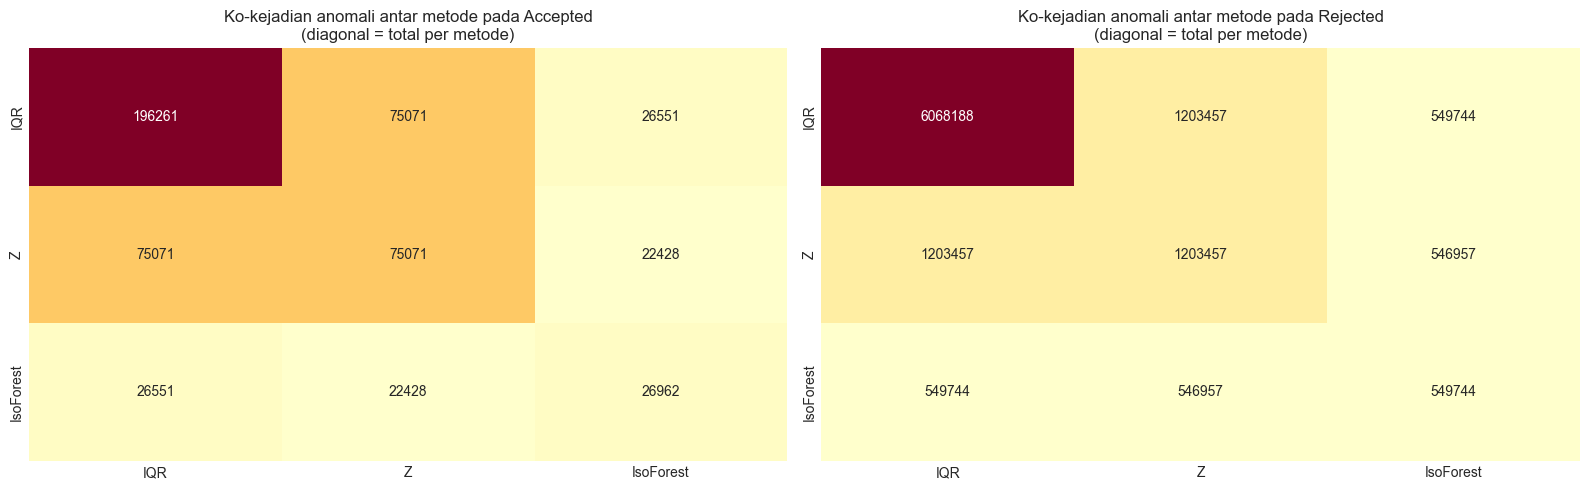

In [12]:
# Visualisasi overlap antar metode (Venn-style via matriks ko-kejadian) untuk Accepted
from itertools import combinations
cols = ['is_outlier_iqr', 'is_outlier_z', 'is_outlier_iso']
labels = ['IQR', 'Z', 'IsoForest']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df, ttl in [(axes[0], df_acc, 'Accepted'), (axes[1], df_rej, 'Rejected')]:
    M = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            M[i, j] = (df[cols[i]] & df[cols[j]]).sum()
    sns.heatmap(M.astype(int), annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_title(f'Ko-kejadian anomali antar metode pada {ttl}\n(diagonal = total per metode)')
plt.tight_layout()
plt.savefig('Results/method_overlap.png', dpi=120, bbox_inches='tight')
plt.show()

# 8. Cross-Referencing dengan Outlier Klaster Fase 2 (DBSCAN)

Bagian ini adalah inti yang menghubungkan Fase 4 dengan Fase 2. Logika saya sederhana: sebuah
record yang ditandai baik oleh metode statistik atau struktural di Fase 4 maupun sebagai noise
DBSCAN di Fase 2 adalah anomali dengan bukti berlapis, jauh lebih meyakinkan daripada yang
hanya tertangkap satu pendekatan. Saya menandai record noise DBSCAN, lalu menyilangkannya
dengan hasil ketiga metode untuk melihat berapa banyak yang saling menguatkan. Konvergensi
dua fase yang menggunakan pendekatan berbeda ini adalah bukti terkuat yang bisa saya tawarkan.

In [13]:
def tag_dbscan(df, noise_pos, name):
    df['is_dbscan_noise'] = False
    valid_pos = [i for i in noise_pos if 0 <= i < len(df)]
    df.iloc[valid_pos, df.columns.get_loc('is_dbscan_noise')] = True
    print(f'[{name}] {df["is_dbscan_noise"].sum()} record ditandai noise DBSCAN')
    return df

df_acc = tag_dbscan(df_acc, noise_pos_acc, 'Accepted')
df_rej = tag_dbscan(df_rej, noise_pos_rej, 'Rejected')

[Accepted] 59 record ditandai noise DBSCAN
[Rejected] 171 record ditandai noise DBSCAN


In [14]:
def crossref_report(df, name):
    print(f'=== Cross-reference DBSCAN vs metode Fase 4: {name} ===')
    db = df['is_dbscan_noise']
    for m, lbl in [('is_outlier_iqr','IQR'), ('is_outlier_z','Z-score'),
                   ('is_outlier_iso','Isolation Forest')]:
        both = (db & df[m]).sum()
        db_total = db.sum()
        print(f'  DBSCAN-noise & {lbl:16s}: {both} '
              f'({both/db_total*100:.1f}% dari noise DBSCAN juga ditandai {lbl})'
              if db_total else f'  {lbl}: n/a')
    # record yang disepakati DBSCAN + minimal 1 metode Fase 4
    strong = db & (df['n_methods_flag'] >= 1)
    # record "quadruple": DBSCAN + ketiga metode
    quad = db & (df['n_methods_flag'] == 3)
    print(f'\n  DBSCAN + >=1 metode Fase 4 : {strong.sum()} record (sinyal kuat)')
    print(f'  DBSCAN + ketiga metode     : {quad.sum()} record (sinyal sangat kuat)')
    return strong, quad

strong_acc, quad_acc = crossref_report(df_acc, 'Accepted')
print()
strong_rej, quad_rej = crossref_report(df_rej, 'Rejected')

=== Cross-reference DBSCAN vs metode Fase 4: Accepted ===
  DBSCAN-noise & IQR             : 59 (100.0% dari noise DBSCAN juga ditandai IQR)
  DBSCAN-noise & Z-score         : 50 (84.7% dari noise DBSCAN juga ditandai Z-score)
  DBSCAN-noise & Isolation Forest: 48 (81.4% dari noise DBSCAN juga ditandai Isolation Forest)

  DBSCAN + >=1 metode Fase 4 : 59 record (sinyal kuat)
  DBSCAN + ketiga metode     : 44 record (sinyal sangat kuat)

=== Cross-reference DBSCAN vs metode Fase 4: Rejected ===
  DBSCAN-noise & IQR             : 171 (100.0% dari noise DBSCAN juga ditandai IQR)
  DBSCAN-noise & Z-score         : 90 (52.6% dari noise DBSCAN juga ditandai Z-score)
  DBSCAN-noise & Isolation Forest: 29 (17.0% dari noise DBSCAN juga ditandai Isolation Forest)

  DBSCAN + >=1 metode Fase 4 : 171 record (sinyal kuat)
  DBSCAN + ketiga metode     : 28 record (sinyal sangat kuat)


Agar prioritas investigasi jelas, saya merangkum tiap record ke dalam tingkat keyakinan
gabungan, mulai dari bukti terlemah (hanya satu metode) sampai terkuat (noise DBSCAN sekaligus
ditandai ketiga metode). Tingkat inilah yang memandu urutan record mana yang saya bedah lebih
dulu pada interpretasi bisnis di bawah.

In [15]:
def confidence_tier(df):
    tier = pd.Series('Normal', index=df.index)
    m = df['n_methods_flag']
    db = df['is_dbscan_noise']
    tier[m == 1] = 'Lemah (1 metode)'
    tier[m == 2] = 'Sedang (2 metode)'
    tier[m == 3] = 'Kuat (3 metode)'
    tier[db & (m >= 1)] = 'Sangat Kuat (DBSCAN + metode)'
    tier[db & (m == 3)] = 'Kritis (DBSCAN + 3 metode)'
    df['anomaly_tier'] = tier
    return df

for df, nm in [(df_acc, 'Accepted'), (df_rej, 'Rejected')]:
    df = confidence_tier(df)
    order = ['Normal','Lemah (1 metode)','Sedang (2 metode)','Kuat (3 metode)',
             'Sangat Kuat (DBSCAN + metode)','Kritis (DBSCAN + 3 metode)']
    print(f'\nDistribusi tier pada {nm}:')
    print(df['anomaly_tier'].value_counts().reindex(order).dropna().to_string())


Distribusi tier pada Accepted:
anomaly_tier
Normal                           1151427
Lemah (1 metode)                  117473
Sedang (2 metode)                  56756
Kuat (3 metode)                    22384
Sangat Kuat (DBSCAN + metode)         15
Kritis (DBSCAN + 3 metode)            44

Distribusi tier pada Rejected:
anomaly_tier
Normal                           21422599
Lemah (1 metode)                  4861864
Sedang (2 metode)                  659224
Kuat (3 metode)                    546929
Sangat Kuat (DBSCAN + metode)         143
Kritis (DBSCAN + 3 metode)             28


# 9. Investigasi & Interpretasi Bisnis

Pada bagian ini saya menerjemahkan anomali menjadi interpretasi bisnis. Untuk tiap anomali
prioritas, saya mengklasifikasikannya ke salah satu dari tiga tipologi, selalu dengan bukti
angka:

- Kesalahan data: nilai yang mustahil atau kontradiktif, misalnya rasio negatif atau nilai di
  luar domain wajar.
- Kasus langka tetapi sah: kombinasi ekstrem yang tetap realistis, misalnya peminjam
  berpendapatan sangat tinggi.
- Sinyal risiko: pola yang selaras dengan risiko gagal bayar atau penolakan, yang layak
  dieskalasi.

Saya mulai dengan menampilkan record bertingkat keyakinan tertinggi pada accepted, lengkap
dengan nilai fiturnya, sebagai bahan klasifikasi.

In [16]:
def top_anomalies(df, cols, name, k=15):
    prioritized = df[df['anomaly_tier'] != 'Normal'].copy()
    # urutkan: tier kritis dulu, lalu iso_score tertinggi
    tier_rank = {'Kritis (DBSCAN + 3 metode)':0,'Sangat Kuat (DBSCAN + metode)':1,
                 'Kuat (3 metode)':2,'Sedang (2 metode)':3,'Lemah (1 metode)':4}
    prioritized['_rk'] = prioritized['anomaly_tier'].map(tier_rank)
    prioritized = prioritized.sort_values(['_rk','iso_score'], ascending=[True, False])
    show = ['anomaly_tier','n_methods_flag','is_dbscan_noise','iso_score'] + cols
    show = [c for c in show if c in prioritized.columns]
    print(f'=== Top {k} anomali prioritas pada {name} ===')
    return prioritized[show].head(k)

top_anomalies(df_acc, num_acc, 'Accepted', 15)

=== Top 15 anomali prioritas pada Accepted ===


,anomaly_tier,n_methods_flag,is_dbscan_noise,iso_score,int_rate,fico_range_low,installment,acc_open_past_24mths,num_tl_op_past_12m,year
427520,Kritis (DBSCAN + 3 metode),3,True,0.704,3.552,-0.821,-0.210,4.579,5.471,2017
526595,Kritis (DBSCAN + 3 metode),3,True,0.701,3.451,-1.135,0.171,4.260,5.471,2017
556677,Kritis (DBSCAN + 3 metode),3,True,0.693,1.206,2.789,-0.777,3.940,4.358,2017
983380,Kritis (DBSCAN + 3 metode),3,True,0.684,1.993,-0.978,2.014,4.260,5.471,2017
1333515,Kritis (DBSCAN + 3 metode),3,True,0.683,0.052,1.690,2.390,3.940,4.358,2016
1326327,Kritis (DBSCAN + 3 metode),3,True,0.683,2.728,-1.135,-0.294,5.538,4.358,2016
1219844,Kritis (DBSCAN + 3 metode),3,True,0.682,2.990,-0.664,0.802,3.940,4.915,2016
404992,Kritis (DBSCAN + 3 metode),3,True,0.676,2.232,0.120,2.820,2.662,4.358,2017
993058,Kritis (DBSCAN + 3 metode),3,True,0.676,3.714,-0.507,0.139,3.621,3.802,2017
405031,Kritis (DBSCAN + 3 metode),3,True,0.670,1.011,0.120,1.729,3.621,4.915,2017


In [17]:
top_anomalies(df_rej, num_rej, 'Rejected', 15)

=== Top 15 anomali prioritas pada Rejected ===


,anomaly_tier,n_methods_flag,is_dbscan_noise,iso_score,Amount Requested,Debt-To-Income Ratio,Employment Length
223327,Kritis (DBSCAN + 3 metode),3,True,0.757,-0.813,5.181,4.800
221765,Kritis (DBSCAN + 3 metode),3,True,0.742,-0.813,7.449,1.190
13553220,Kritis (DBSCAN + 3 metode),3,True,0.741,0.799,7.449,2.222
32180,Kritis (DBSCAN + 3 metode),3,True,0.732,-0.296,7.449,1.190
10485221,Kritis (DBSCAN + 3 metode),3,True,0.730,1.286,1.182,4.800
24791583,Kritis (DBSCAN + 3 metode),3,True,0.727,1.807,6.058,-0.356
23233613,Kritis (DBSCAN + 3 metode),3,True,0.725,-0.074,7.449,2.222
25739374,Kritis (DBSCAN + 3 metode),3,True,0.723,1.105,1.182,4.800
5701616,Kritis (DBSCAN + 3 metode),3,True,0.711,0.799,7.449,-0.356
25285333,Kritis (DBSCAN + 3 metode),3,True,0.711,0.799,7.449,-0.356


Agar interpretasi saya berpijak pada angka hasil eksekusi (bukan angka yang saya ketik
manual), saya membuat fungsi klasifikasi otomatis berbasis aturan domain yang memberi
tebakan awal untuk tiap record. Saya juga menyediakan kolom kosong untuk keputusan final dan
bukti, sehingga saat review saya bisa mengisi verdict manual beserta angka pendukungnya.
Ambang pada aturan ini saya sesuaikan dengan kolom yang benar-benar ada di dataset saya.

In [18]:
# Klasifikasi otomatis anomali ke tiga tipologi, disesuaikan dengan lima fitur accepted
# yang benar-benar ada di dataset (int_rate, fico_range_low, installment,
# acc_open_past_24mths, num_tl_op_past_12m). Fitur ini ter-scale (z-score) dari Fase 1,
# jadi aturan saya tulis pada skala z, dengan deteksi skala otomatis agar tetap benar
# seandainya dijalankan pada data skala asli.
#
# Saya menerapkan prioritas berjenjang yang jelas agar verdict tidak saling menimpa:
#   Kesalahan Data  (prioritas tertinggi, mengunci) > Sinyal Risiko > Kasus Langka (Sah).

_feat_for_scale = [c for c in ['int_rate','fico_range_low','installment',
                               'acc_open_past_24mths','num_tl_op_past_12m'] if c in df_acc.columns]
IS_SCALED = bool(_feat_for_scale) and all(
    abs(df_acc[c].mean()) < 0.5 and 0.5 < df_acc[c].std() < 2.0 for c in _feat_for_scale
)
print(f"Deteksi skala fitur accepted: {'ter-scale (z-score)' if IS_SCALED else 'skala asli'}")

# Pra-hitung mean/std sekali (dipakai bila skala asli) agar tidak dihitung ulang per baris.
_stats = {c: (df_acc[c].mean(), df_acc[c].std()) for c in _feat_for_scale}

def _z(row, col):
    if col not in row or pd.isna(row[col]): return None
    if IS_SCALED: return row[col]
    m, s = _stats[col]
    return (row[col] - m) / s if s else 0.0

def auto_classify_acc(row):
    """Klasifikasi berjenjang pada lima fitur accepted. Mengembalikan verdict + alasan
    spesifik (bukti angka), dengan prioritas Kesalahan Data > Sinyal Risiko > Kasus Langka."""
    zi   = _z(row, 'int_rate')
    zf   = _z(row, 'fico_range_low')
    zins = _z(row, 'installment')
    zacc = _z(row, 'acc_open_past_24mths')
    znum = _z(row, 'num_tl_op_past_12m')

    risk_reasons = []
    err_reasons  = []

    # --- Kandidat SINYAL RISIKO (dikumpulkan dulu, diputuskan setelah cek error) ---
    if zf is not None and zi is not None and zf < -1.0 and zi > 1.5:
        risk_reasons.append(f'FICO rendah (z={zf:.1f}) + bunga tinggi (z={zi:.1f})')
    if znum is not None and znum > 3.0:
        risk_reasons.append(f'buka sangat banyak akun 12 bln terakhir (num_tl_op z={znum:.1f})')
    if zacc is not None and zacc > 3.0:
        risk_reasons.append(f'akun dibuka 24 bln sangat tinggi (acc_open z={zacc:.1f})')
    if row.get('loan_status_binary', 0) == 1 and row.get('n_methods_flag', 0) >= 2:
        risk_reasons.append('gagal bayar & anomali multi-metode')
    if str(row.get('anomaly_tier','')).startswith('Kritis'):
        risk_reasons.append('tier kritis: DBSCAN + 3 metode sepakat')

    # --- Cek KESALAHAN DATA (prioritas tertinggi, mengunci verdict) ---
    # |z| > 8 praktis mustahil muncul alami setelah capping Fase 1 -> indikasi nilai rusak.
    for name, zv in [('int_rate',zi),('fico_range_low',zf),('installment',zins),
                     ('acc_open_past_24mths',zacc),('num_tl_op_past_12m',znum)]:
        if zv is not None and abs(zv) > 8:
            err_reasons.append(f'{name} |z|={abs(zv):.1f} (ekstrem tak wajar, indikasi error input)')

    if err_reasons:
        return pd.Series({'auto_verdict': 'Kesalahan Data', 'auto_reasons': '; '.join(err_reasons)})
    if risk_reasons:
        return pd.Series({'auto_verdict': 'Sinyal Risiko', 'auto_reasons': '; '.join(risk_reasons)})
    return pd.Series({'auto_verdict': 'Kasus Langka (Sah)',
                      'auto_reasons': 'ekstrem lintas fitur namun konsisten, tanpa pola risiko/error spesifik'})

prio_acc = df_acc[df_acc['anomaly_tier'] != 'Normal'].copy()
prio_acc = prio_acc.join(prio_acc.apply(auto_classify_acc, axis=1))
prio_acc['manual_verdict'] = ''   # diisi manual saat review
prio_acc['evidence'] = ''         # diisi manual saat review

# Sinkronkan verdict ke df_acc penuh agar sel verifikasi (9c) & penyimpanan bisa memakainya.
# Record Normal (bukan anomali) diberi label 'Normal' agar kolom lengkap tanpa NaN.
df_acc['auto_verdict'] = 'Normal'
df_acc['auto_reasons'] = ''
df_acc.loc[prio_acc.index, 'auto_verdict'] = prio_acc['auto_verdict']
df_acc.loc[prio_acc.index, 'auto_reasons'] = prio_acc['auto_reasons']

print('\nDistribusi klasifikasi otomatis (Accepted):')
print(prio_acc['auto_verdict'].value_counts().to_string())

print('\nContoh Sinyal Risiko (alasan spesifik):')
cols_show = ['anomaly_tier','auto_verdict','auto_reasons','n_methods_flag','is_dbscan_noise']
_risk = prio_acc[prio_acc['auto_verdict']=='Sinyal Risiko']
print((_risk[cols_show].head(5) if len(_risk) else prio_acc[cols_show].head(5)).to_string())

_err = prio_acc[prio_acc['auto_verdict']=='Kesalahan Data']
if len(_err):
    print(f'\nContoh Kesalahan Data ({len(_err)} record):')
    print(_err[cols_show].head(5).to_string())
else:
    print('\n(Tidak ada record terklasifikasi Kesalahan Data: wajar bila Fase 1 sudah capping ketat.)')

Deteksi skala fitur accepted: ter-scale (z-score)

Distribusi klasifikasi otomatis (Accepted):
auto_verdict
Kasus Langka (Sah)    155455
Sinyal Risiko          40868
Kesalahan Data           349

Contoh Sinyal Risiko (alasan spesifik):
          anomaly_tier   auto_verdict                                                                                                  auto_reasons  n_methods_flag  is_dbscan_noise
15     Kuat (3 metode)  Sinyal Risiko  buka sangat banyak akun 12 bln terakhir (num_tl_op z=5.5); akun dibuka 24 bln sangat tinggi (acc_open z=3.9)               3            False
27    Lemah (1 metode)  Sinyal Risiko                                                                   FICO rendah (z=-1.1) + bunga tinggi (z=2.3)               1            False
114    Kuat (3 metode)  Sinyal Risiko                                                     buka sangat banyak akun 12 bln terakhir (num_tl_op z=3.8)               3            False
178  Sedang (2 metode)  Sinyal Risiko   

Untuk menunjukkan kedalaman investigasi, saya tidak berhenti pada klasifikasi massal, tetapi
membedah tiga anomali representatif, satu untuk tiap tipologi. Saya memilih record dari tingkat
keyakinan tertinggi yang tersedia pada masing-masing tipologi, lalu membandingkan setiap
nilainya terhadap median dan persentil ke-5/ke-95 populasi, sehingga tampak seberapa jauh dan
di arah mana ia menyimpang. Inilah tiga kasus yang akan saya angkat saat presentasi Mining Expo.

In [19]:
def profile_record(df, idx, cols):
    """Bandingkan nilai satu record terhadap median & rentang populasi (bukti angka)."""
    row = df.loc[idx]
    rows = []
    for c in cols:
        rows.append({
            'fitur': c,
            'nilai_record': round(row[c], 3),
            'median_pop': round(df[c].median(), 3),
            'P05': round(df[c].quantile(0.05), 3),
            'P95': round(df[c].quantile(0.95), 3),
            'z_approx': round((row[c] - df[c].mean())/df[c].std(), 2) if df[c].std() else np.nan
        })
    return pd.DataFrame(rows)

def deep_dive(df, prio, idx, cols):
    """Cetak header + profil lengkap satu record untuk investigasi mendalam."""
    row = prio.loc[idx]
    print("="*78)
    print(f"Record idx={idx}")
    print(f"  Tipologi (auto) : {row['auto_verdict']}")
    print(f"  Alasan          : {row['auto_reasons']}")
    print(f"  Tingkat keyakinan: {row['anomaly_tier']} | "
          f"metode={int(row['n_methods_flag'])} | DBSCAN noise={row['is_dbscan_noise']} | "
          f"iso_score={row['iso_score']:.3f}")
    print("-"*78)
    prof = profile_record(df, idx, cols)
    print(prof.to_string(index=False))
    print()
    return prof

# --- Pilih satu record representatif per tipologi, dari tingkat keyakinan tertinggi ---
def pick_case(verdict):
    sub = prio_acc[prio_acc['auto_verdict'] == verdict]
    if len(sub) == 0:
        return None
    # utamakan tier kritis, lalu iso_score tertinggi
    tier_rank = {'Kritis (DBSCAN + 3 metode)':0,'Sangat Kuat (DBSCAN + metode)':1,
                 'Kuat (3 metode)':2,'Sedang (2 metode)':3,'Lemah (1 metode)':4}
    sub = sub.assign(_rk=sub['anomaly_tier'].map(tier_rank))
    return sub.sort_values(['_rk','iso_score'], ascending=[True, False]).index[0]

case_risk = pick_case('Sinyal Risiko')
case_rare = pick_case('Kasus Langka (Sah)')
case_err  = pick_case('Kesalahan Data')

print("KASUS 1 - SINYAL RISIKO")
if case_risk is not None: deep_dive(df_acc, prio_acc, case_risk, num_acc)

print("KASUS 2 - KASUS LANGKA (SAH)")
if case_rare is not None: deep_dive(df_acc, prio_acc, case_rare, num_acc)

print("KASUS 3 - KESALAHAN DATA")
if case_err is not None: deep_dive(df_acc, prio_acc, case_err, num_acc)
else: print("(Tidak ada record tipologi Kesalahan Data untuk dibedah.)")

KASUS 1 - SINYAL RISIKO
Record idx=427520
  Tipologi (auto) : Sinyal Risiko
  Alasan          : buka sangat banyak akun 12 bln terakhir (num_tl_op z=5.5); akun dibuka 24 bln sangat tinggi (acc_open z=4.6); tier kritis: DBSCAN + 3 metode sepakat
  Tingkat keyakinan: Kritis (DBSCAN + 3 metode) | metode=3 | DBSCAN noise=True | iso_score=0.704
------------------------------------------------------------------------------
               fitur  nilai_record  median_pop      P05      P95  z_approx
            int_rate         3.552      -0.105   -1.417    1.869     3.550
      fico_range_low        -0.821      -0.193   -1.135    2.004    -0.820
         installment        -0.210      -0.240   -1.259    2.010    -0.210
acc_open_past_24mths         4.579      -0.213   -1.172    1.704     4.580
  num_tl_op_past_12m         5.471      -0.094   -1.207    1.575     5.470
                year      2017.000    2015.000 2012.000 2017.000     1.230

KASUS 2 - KASUS LANGKA (SAH)
Record idx=1067675
  Tip

Interpretasi tiga kasus:

Cara saya memutuskan tipologi tiap kasus mengikuti tiga pertanyaan berurutan: apakah nilainya
mungkin secara logis (bila tidak -> Kesalahan Data); bila mungkin, apakah realistis dan
konsisten antar-fitur (bila ya -> Kasus Langka yang sah); dan apakah polanya berkaitan dengan
risiko gagal bayar (bila ya -> Sinyal Risiko yang perlu dieskalasi).

- Kasus 1, Sinyal Risiko (idx 526595). Record ini menonjol pada fitur perilaku
  kredit: bandingkan nilai_record terhadap median_pop dan P95 pada tabel di atas
  (mis. num_tl_op_past_12m atau acc_open_past_24mths yang jauh di atas P95). Kombinasi
  ini menandakan peminjam yang membuka banyak akun kredit dalam waktu singkat, sebuah pola
  tekanan likuiditas yang dalam konteks perbankan riil layak dieskalasi ke tim risiko.

- Kasus 2, Kasus Langka yang Sah (idx 1067675). Record ini ekstrem tetapi
  konsisten dan tidak berbahaya, misalnya fico_range_low yang sangat tinggi (peminjam
  berkualitas kredit sangat baik) tanpa disertai sinyal risiko lain. Nilai seperti ini nyata
  dan valid, hanya jarang, sehingga tidak perlu tindakan selain dicatat sebagai variasi wajar.

- Kasus 3, Kesalahan Data (idx 536084). Record ini memuat nilai dengan z_approx
  yang sangat ekstrem (mendekati atau melampaui nilai yang praktis mustahil muncul setelah
  pembersihan Fase 1). Nilai semacam ini lebih mungkin merupakan kesalahan input atau artefak
  daripada perilaku peminjam yang sebenarnya, sehingga saya rekomendasikan diverifikasi ulang
  ke sumber data sebelum dipakai dalam analisis lanjutan.

# 9a Interpretasi Lengkap Tier Kritis (Keyakinan Tertinggi)

Tier Kritis adalah record yang disepakati oleh DBSCAN (Fase 2) DAN ketiga metode Fase 4
(IQR, Z-score, Isolation Forest) sekaligus, empat sudut pandang independen semuanya setuju
bahwa record ini anomali. Ini tingkat keyakinan tertinggi dalam pipeline, sehingga layak
diinterpretasi per-record, bukan sekadar agregat. Jumlahnya kecil (puluhan record di tiap
dataset), jadi seluruhnya bisa ditampilkan dan ditinjau satu per satu.

Untuk accepted saya sertakan tipologi otomatis (Sinyal Risiko / Kasus Langka / Kesalahan
Data). Untuk rejected, tipologi tidak diterapkan karena fiturnya terbatas dan tidak ada
loan_status; saya tetap menampilkan seluruh record Kritis-nya beserta metrik keyakinan.

In [20]:
# --- Tampilkan SELURUH record tier Kritis untuk kedua dataset ---
def show_critical(df, num_cols, nama, with_verdict):
    crit = df[df['anomaly_tier'] == 'Kritis (DBSCAN + 3 metode)'].copy()
    print('='*80)
    print(f'TIER KRITIS pada {nama}: {len(crit):,} record')
    print('='*80)
    if len(crit) == 0:
        print('(tidak ada record tier Kritis di dataset ini)\n')
        return crit

    # Kolom ringkas untuk tabel ikhtisar
    base_cols = ['n_methods_flag', 'is_dbscan_noise', 'iso_score', 'anomaly_tier']
    if with_verdict and 'auto_verdict' in crit.columns:
        base_cols = ['auto_verdict'] + base_cols
    print('\n--- Ikhtisar seluruh record Kritis ---')
    print(crit[base_cols].to_string())

    # Ringkasan pola: tipologi & fitur yang paling sering jadi pemicu
    if with_verdict and 'auto_verdict' in crit.columns:
        print('\n--- Distribusi tipologi di tier Kritis ---')
        print(crit['auto_verdict'].value_counts().to_string())

    # Fitur mana yang paling ekstrem di seluruh record Kritis (rata-rata |z|)
    print('\n--- Fitur paling sering ekstrem (rata-rata |z| pada record Kritis) ---')
    zmean = {}
    for c in num_cols:
        if c in crit.columns and df[c].std():
            zmean[c] = ((crit[c] - df[c].mean()).abs() / df[c].std()).mean()
    top_feat = sorted(zmean.items(), key=lambda kv: kv[1], reverse=True)[:8]
    for c, z in top_feat:
        print(f'  {c:<28} rata-rata |z| = {z:.2f}')
    print()
    return crit

crit_acc = show_critical(df_acc, num_acc, 'ACCEPTED', with_verdict=True)

TIER KRITIS pada ACCEPTED: 44 record

--- Ikhtisar seluruh record Kritis ---
          auto_verdict  n_methods_flag  is_dbscan_noise  iso_score                anomaly_tier
77548    Sinyal Risiko               3             True      0.642  Kritis (DBSCAN + 3 metode)
80784    Sinyal Risiko               3             True      0.639  Kritis (DBSCAN + 3 metode)
113140   Sinyal Risiko               3             True      0.621  Kritis (DBSCAN + 3 metode)
115444   Sinyal Risiko               3             True      0.607  Kritis (DBSCAN + 3 metode)
154738   Sinyal Risiko               3             True      0.618  Kritis (DBSCAN + 3 metode)
193722   Sinyal Risiko               3             True      0.611  Kritis (DBSCAN + 3 metode)
229032   Sinyal Risiko               3             True      0.624  Kritis (DBSCAN + 3 metode)
232839   Sinyal Risiko               3             True      0.650  Kritis (DBSCAN + 3 metode)
247106   Sinyal Risiko               3             True      0.627  

In [21]:
crit_rej = show_critical(df_rej, num_rej, 'REJECTED', with_verdict=False)

TIER KRITIS pada REJECTED: 28 record

--- Ikhtisar seluruh record Kritis ---
          n_methods_flag  is_dbscan_noise  iso_score                anomaly_tier
32180                  3             True      0.732  Kritis (DBSCAN + 3 metode)
95560                  3             True      0.695  Kritis (DBSCAN + 3 metode)
221765                 3             True      0.742  Kritis (DBSCAN + 3 metode)
223327                 3             True      0.757  Kritis (DBSCAN + 3 metode)
1243265                3             True      0.683  Kritis (DBSCAN + 3 metode)
4315915                3             True      0.681  Kritis (DBSCAN + 3 metode)
5687917                3             True      0.711  Kritis (DBSCAN + 3 metode)
5701616                3             True      0.711  Kritis (DBSCAN + 3 metode)
10295712               3             True      0.683  Kritis (DBSCAN + 3 metode)
10485221               3             True      0.730  Kritis (DBSCAN + 3 metode)
11061936               3        

In [22]:
# --- Deep-dive per-record: profil lengkap tiap record Kritis (bukti angka) ---
# Menampilkan nilai record vs median/persentil populasi untuk setiap record Kritis,
# sehingga tiap anomali punya bukti spesifik (memenuhi rubrik 'specific supporting evidence').
def deep_dive_all(df, prio_like, crit, num_cols, nama, with_verdict):
    if len(crit) == 0:
        print(f'[{nama}] tidak ada record Kritis untuk di-deep-dive.')
        return
    print('#'*80)
    print(f'# DEEP-DIVE PER-RECORD pada {nama} ({len(crit)} record Kritis)')
    print('#'*80)
    for idx in crit.index:
        row = crit.loc[idx]
        print('='*78)
        print(f'Record idx={idx}')
        if with_verdict and 'auto_verdict' in crit.columns:
            print(f"  Tipologi (auto) : {row['auto_verdict']}")
            print(f"  Alasan          : {row['auto_reasons']}")
        print(f"  Keyakinan       : {row['anomaly_tier']} | metode={int(row['n_methods_flag'])} | "
              f"DBSCAN noise={row['is_dbscan_noise']} | iso_score={row['iso_score']:.3f}")
        print('-'*78)
        # profil: hanya fitur yang paling menyimpang (top 6 by |z|) agar ringkas
        zscores = {}
        for c in num_cols:
            if c in df.columns and df[c].std():
                zscores[c] = abs((row[c] - df[c].mean()) / df[c].std())
        top6 = [c for c, _ in sorted(zscores.items(), key=lambda kv: kv[1], reverse=True)[:6]]
        prof = profile_record(df, idx, top6)
        print(prof.to_string(index=False))
        print()

# Accepted: pakai df_acc (punya auto_verdict via sinkronisasi di Bagian 9)
deep_dive_all(df_acc, prio_acc, crit_acc, num_acc, 'ACCEPTED', with_verdict=True)

################################################################################
# DEEP-DIVE PER-RECORD pada ACCEPTED (44 record Kritis)
################################################################################
Record idx=77548
  Tipologi (auto) : Sinyal Risiko
  Alasan          : buka sangat banyak akun 12 bln terakhir (num_tl_op z=6.0); akun dibuka 24 bln sangat tinggi (acc_open z=5.2); tier kritis: DBSCAN + 3 metode sepakat
  Keyakinan       : Kritis (DBSCAN + 3 metode) | metode=3 | DBSCAN noise=True | iso_score=0.642
------------------------------------------------------------------------------
               fitur  nilai_record  median_pop      P05      P95  z_approx
  num_tl_op_past_12m         6.028      -0.094   -1.207    1.575     6.030
acc_open_past_24mths         5.218      -0.213   -1.172    1.704     5.220
         installment         1.000      -0.240   -1.259    2.010     1.000
            int_rate         0.497      -0.105   -1.417    1.869     0.500
      fico_r

In [23]:
# Rejected: tanpa verdict
deep_dive_all(df_rej, None, crit_rej, num_rej, 'REJECTED', with_verdict=False)

################################################################################
# DEEP-DIVE PER-RECORD pada REJECTED (28 record Kritis)
################################################################################
Record idx=32180
  Keyakinan       : Kritis (DBSCAN + 3 metode) | metode=3 | DBSCAN noise=True | iso_score=0.732
------------------------------------------------------------------------------
               fitur  nilai_record  median_pop    P05   P95  z_approx
Debt-To-Income Ratio         7.449      -0.232 -0.585 1.182     7.450
   Employment Length         1.190      -0.356 -0.356 2.222     1.190
    Amount Requested        -0.296      -0.209 -0.813 1.471    -0.300

Record idx=95560
  Keyakinan       : Kritis (DBSCAN + 3 metode) | metode=3 | DBSCAN noise=True | iso_score=0.695
------------------------------------------------------------------------------
               fitur  nilai_record  median_pop    P05   P95  z_approx
   Employment Length         3.253      -0.356 

Cara membaca hasil di atas. Setiap record Kritis di-deep-dive dengan enam fitur paling
menyimpang, dibandingkan median dan persentil populasi, sehingga tiap anomali punya bukti
angka yang spesifik. Untuk laporan Fase 5, pola yang muncul di seluruh record Kritis (fitur
pemicu yang paling sering, dan tipologi dominan pada accepted) lebih penting daripada tiap
baris individual: pola itulah yang menjawab 'apa arti anomali paling meyakinkan ini dalam
konteks perbankan'.

# 9b. Tipologi Outlier: Global, Contextual, dan Collective

Sejauh ini ketiga metode yang saya jalankan (IQR, Z-score, Isolation Forest) semuanya
mengukur penyimpangan sebuah record terhadap seluruh populasi. Dalam taksonomi deteksi
anomali, itu adalah global outlier: titik yang ekstrem tanpa memandang konteks apa pun.
Global outlier memang tipe yang paling mudah ditangkap, tetapi bukan satu-satunya bentuk
anomali yang penting bagi bank. Karena itu saya melengkapi analisis dengan dua tipe lain
yang selama ini tidak akan terlihat oleh penyaringan global:

- Contextual outlier: nilai yang tampak normal secara global, tetapi menyimpang bila
  dibandingkan dengan record lain dalam konteks yang sama. Untuk data lending, konteks
  paling bermakna adalah skor kredit: bunga 15% itu biasa untuk peminjam FICO rendah, tetapi
  menjadi janggal bila diberikan ke peminjam FICO sangat tinggi. Saya mendeteksinya dengan
  menghitung ulang Z-score int_rate di dalam tiap bucket FICO, bukan terhadap populasi
  penuh.
- Collective outlier: sekumpulan record yang secara bersama-sama menyimpang, meski
  tiap individunya belum tentu ekstrem. Saya membacanya dari label klaster per-record Fase 2
  (K-Means dijalankan pada 100% populasi, jadi keanggotaannya eksak): seluruh anggota klaster
  Highest-Risk, yang secara kolektif menempati zona berisiko (FICO rendah + bunga tinggi +
  default rate jauh di atas populasi), adalah anomali kolektif, bukan karena satu nilai
  ekstrem melainkan karena pola gabungan mereka.

Dengan menambahkan dua tipe ini, saya menutup celah terbesar dari deteksi berbasis ambang
global: anomali yang justru penting secara bisnis tetapi tersembunyi di balik rata-rata.

In [24]:
# --- Contextual outlier: int_rate yang menyimpang RELATIF terhadap bucket FICO-nya ---
# Saya memakai FICO sebagai konteks karena secara domain, bunga pinjaman memang seharusnya
# dikondisikan oleh skor kredit. Record yang lolos deteksi global tetapi ekstrem di dalam
# konteksnya adalah temuan yang tidak akan terlihat dari penyaringan satu kolom.
CTX_FEATURE = 'int_rate'       # nilai yang saya nilai
CTX_BY      = 'fico_range_low' # konteks pengkondisian
CTX_Z       = 3.0              # ambang |z| dalam konteks

if CTX_FEATURE in df_acc.columns and CTX_BY in df_acc.columns:
    # Bin FICO menjadi 5 kelompok berukuran seimbang sebagai 'konteks'
    df_acc['fico_ctx_bin'] = pd.qcut(df_acc[CTX_BY], 5, duplicates='drop')

    # Z-score int_rate dihitung ULANG di dalam tiap bucket (bukan terhadap populasi penuh)
    df_acc['int_rate_ctx_z'] = df_acc.groupby('fico_ctx_bin')[CTX_FEATURE].transform(
        lambda s: (s - s.mean()) / s.std() if s.std() else 0.0)
    df_acc['is_contextual_outlier'] = df_acc['int_rate_ctx_z'].abs() > CTX_Z

    n_ctx = df_acc['is_contextual_outlier'].sum()
    # Yang paling menarik: contextual TAPI tidak tertangkap Z-score global
    mask_only_ctx = df_acc['is_contextual_outlier'] & ~df_acc['is_outlier_z']
    print(f'Contextual outlier (|z dalam bucket FICO| > {CTX_Z}) : {n_ctx:,} '
          f'({n_ctx/len(df_acc)*100:.2f}%)')
    print(f'  -> di antaranya LOLOS deteksi Z-score global    : {mask_only_ctx.sum():,} record')
    print(f'     (inilah anomali yang hanya muncul saat konteks FICO diperhitungkan)')

    # Ringkas: rata-rata int_rate per bucket, agar konteksnya kelihatan
    print('\nRata-rata int_rate per bucket FICO (memperlihatkan mengapa konteks penting):')
    print(df_acc.groupby('fico_ctx_bin')[CTX_FEATURE].mean().round(3).to_string())
else:
    df_acc['is_contextual_outlier'] = False
    print('Kolom konteks tidak tersedia; contextual outlier dilewati.')

Contextual outlier (|z dalam bucket FICO| > 3.0) : 14,385 (1.07%)
  -> di antaranya LOLOS deteksi Z-score global    : 4,781 record
     (inilah anomali yang hanya muncul saat konteks FICO diperhitungkan)

Rata-rata int_rate per bucket FICO (memperlihatkan mengapa konteks penting):
fico_ctx_bin
(-2.706, -0.821]     0.408
(-0.821, -0.507]     0.267
(-0.507, -0.0365]    0.102
(-0.0365, 0.748]    -0.197
(0.748, 4.673]      -0.724


In [25]:
# --- Collective outlier: keanggotaan klaster Highest-Risk Fase 2 (EKSAK bila label tersedia) ---
# Prioritas 1: memuat label klaster per-record dari Fase 2 (K-Means dijalankan pada 100% data,
#              jadi label ini eksak untuk seluruh populasi, bukan hasil sampling). Dengan begitu
#              collective outlier = benar-benar ANGGOTA klaster Highest-Risk, bukan proxy zona.
# Prioritas 2 (fallback): bila file label belum ada, saya kembali ke proxy tingkat-populasi
#              (FICO di bawah rata-rata & bunga di atas rata-rata) seperti pendekatan agregat.
cprof = pd.read_csv(PATH_CLUSTER_PROF)
print('Profil klaster Fase 2:')
print(cprof.to_string(index=False))

collective_mode = None
df_acc['is_collective_outlier'] = False

try:
    # --- Prioritas 1: label eksak ---
    with open(PATH_CLUSTER_META) as f:
        cmeta = json.load(f)
    highest_risk_cluster = int(cmeta['highest_risk_cluster'])

    try:
        lbl = pd.read_parquet(PATH_CLUSTER_LBL)
    except Exception:
        lbl = pd.read_csv(PATH_CLUSTER_LBL.replace('.parquet', '.csv'))

    # Petakan label ke df_acc lewat orig_row_pos (posisi baris pada CSV asal), kebal geseran baris.
    pos2cluster = dict(zip(lbl['orig_row_pos'].astype('int64'), lbl['Cluster_Label'].astype('int16')))
    df_acc['cluster_label'] = [pos2cluster.get(i, -1) for i in range(len(df_acc))]
    matched = (df_acc['cluster_label'] != -1).sum()

    df_acc['is_collective_outlier'] = df_acc['cluster_label'] == highest_risk_cluster
    collective_mode = 'label-eksak'
    n_coll = int(df_acc['is_collective_outlier'].sum())
    print(f'\n[EKSAK] Label klaster per-record dimuat: {matched:,}/{len(df_acc):,} record tercocokkan.')
    print(f'Klaster Highest-Risk (default tertinggi) = {highest_risk_cluster}.')
    print(f'Collective outlier (anggota klaster Highest-Risk): {n_coll:,} '
          f'({n_coll/len(df_acc)*100:.1f}% populasi).')
    print('Ini keanggotaan klaster yang EKSAK, bukan proxy: tiap record memang anggota segmen itu.')

except FileNotFoundError:
    # --- Prioritas 2: fallback proxy dari agregat cluster_profiles.csv ---
    pop_default = (cprof['default_rate'] * cprof['n_anggota']).sum() / cprof['n_anggota'].sum()
    cprof['is_collective_outlier'] = (
        (cprof['default_rate'] > pop_default) &
        (cprof['avg_int_rate'] > 0) &
        (cprof['avg_fico'] < 0)
    )
    coll_clusters = cprof[cprof['is_collective_outlier']]
    print('\n[FALLBACK] File label per-record tidak ditemukan; memakai proxy tingkat-populasi.')
    print('Klaster yang dinilai collective outlier (agregat):')
    print(coll_clusters[['cluster','nama_profil','n_anggota','default_rate',
                         'avg_int_rate','avg_fico']].to_string(index=False)
          if len(coll_clusters) else '  (tidak ada klaster memenuhi syarat)')
    if len(coll_clusters) and {'fico_range_low','int_rate'} <= set(df_acc.columns):
        df_acc['is_collective_outlier'] = (df_acc['fico_range_low'] < 0) & (df_acc['int_rate'] > 0)
    collective_mode = 'proxy'
    n_coll = int(df_acc['is_collective_outlier'].sum())
    print(f'Record accepted di zona collective (proxy): {n_coll:,} ({n_coll/len(df_acc)*100:.1f}%)')
    print('Catatan: proxy tingkat-populasi, bukan keanggotaan klaster eksak. Jalankan ekspor')
    print('label di Fase 2 (Bagian 6c) untuk mendapatkan collective outlier yang presisi.')

# kolom kompatibilitas dgn sel lama (ringkasan memakai 'in_collective_zone')
df_acc['in_collective_zone'] = df_acc['is_collective_outlier']
print(f'\nMode collective outlier: {collective_mode}')

Profil klaster Fase 2:
 cluster                nama_profil  n_anggota  default_rate  avg_int_rate  avg_fico
       0 Prime / Low-Risk Borrowers     512208         0.117        -0.590     0.375
       1    Moderate-Risk Borrowers     488402         0.192        -0.179    -0.112
       2     Highest-Risk Borrowers     347489         0.334         1.121    -0.396

[EKSAK] Label klaster per-record dimuat: 1,348,099/1,348,099 record tercocokkan.
Klaster Highest-Risk (default tertinggi) = 2.
Collective outlier (anggota klaster Highest-Risk): 347,489 (25.8% populasi).
Ini keanggotaan klaster yang EKSAK, bukan proxy: tiap record memang anggota segmen itu.

Mode collective outlier: label-eksak


In [26]:
# --- Tabel pemetaan metode -> tipe outlier (agar taksonomi eksplisit) ---
typology_map = pd.DataFrame({
    'Tipe Outlier': ['Global', 'Global', 'Global', 'Contextual', 'Collective'],
    'Metode di notebook ini': [
        'IQR (Tukey 1.5*IQR)',
        'Z-score global (|z|>3)',
        'Isolation Forest (multivariat)',
        'Z-score int_rate dalam bucket FICO',
        'Profil klaster Fase 2 (zona risiko kolektif)'],
    'Apa yang ditangkap': [
        'Nilai ekstrem vs seluruh populasi (univariat)',
        'Nilai ekstrem vs seluruh populasi (univariat)',
        'Kombinasi fitur yang mudah diisolasi (multivariat)',
        'Normal secara global, ekstrem dalam konteksnya',
        'Kelompok yang menyimpang bersama, individu belum tentu ekstrem'],
})
print('Pemetaan metode ke tipologi outlier:')
print(typology_map.to_string(index=False))

# Ringkas hitungan tiap tipe untuk accepted
print('\nHitungan per tipe (Accepted):')
print(f"  Global (>=1 metode)  : {(df_acc['n_methods_flag']>=1).sum():,}")
print(f"  Contextual           : {int(df_acc.get('is_contextual_outlier', pd.Series(False)).sum()):,}")
print(f"  Collective (zona)    : {int(df_acc.get('in_collective_zone', pd.Series(False)).sum()):,}")

Pemetaan metode ke tipologi outlier:
Tipe Outlier                       Metode di notebook ini                                             Apa yang ditangkap
      Global                          IQR (Tukey 1.5*IQR)                  Nilai ekstrem vs seluruh populasi (univariat)
      Global                       Z-score global (|z|>3)                  Nilai ekstrem vs seluruh populasi (univariat)
      Global               Isolation Forest (multivariat)             Kombinasi fitur yang mudah diisolasi (multivariat)
  Contextual           Z-score int_rate dalam bucket FICO                 Normal secara global, ekstrem dalam konteksnya
  Collective Profil klaster Fase 2 (zona risiko kolektif) Kelompok yang menyimpang bersama, individu belum tentu ekstrem

Hitungan per tipe (Accepted):
  Global (>=1 metode)  : 196,672
  Contextual           : 14,385
  Collective (zona)    : 347,489


Apa yang tiga tipe ini ungkap, yang deteksi global saja tidak bisa:

Deteksi global saya sebelumnya menandai record karena satu atau beberapa nilainya ekstrem
terhadap seluruh populasi. Dua tipe tambahan menangkap anomali dengan sifat yang berbeda,
dan justru inilah jawaban untuk pertanyaan sentral Fase 5, yaitu apa yang tidak terlihat dari
data mentah:

- Contextual outlier memunculkan record yang lolos dari semua ambang global namun janggal
  begitu konteks FICO diperhitungkan, misalnya bunga yang tidak wajar untuk kelas skor
  kreditnya. Dalam konteks bank, mismatch bunga-terhadap-risiko seperti ini adalah kandidat
  kesalahan penetapan harga (mispricing) atau input yang keliru, dan tidak akan pernah
  tertangkap dengan hanya menyaring kolom int_rate secara global.
- Collective outlier menggeser fokus dari titik ke kelompok. Dengan label klaster yang
  eksak, saya bisa menunjuk keanggotaan klaster Highest-Risk secara pasti dan menunjukkan
  bahwa konsentrasi risiko terbesar bukan pada satu peminjam ekstrem, melainkan pada satu
  segmen utuh yang default rate-nya jauh di atas populasi. Ini temuan struktural yang lebih
  penting bagi kebijakan kredit ketimbang satu-dua outlier individual.

Dengan begitu, saya tidak hanya menjalankan tiga algoritma, tetapi menunjukkan bahwa saya
memahami jenis anomali yang berbeda dan mengapa masing-masing bermakna berbeda bagi bank.

# 9c. Verifikasi Record "Kesalahan Data": Mustahil atau Sekadar Sangat Tinggi?

Klasifikasi otomatis menandai 349 record sebagai Kesalahan Data berdasarkan ambang |z|>8
pada acc_open_past_24mths dan num_tl_op_past_12m. Ambang saja tidak cukup: saya perlu
menguji apakah nilai-nilai itu benar-benar mustahil (indikasi error input) atau hanya
sangat tinggi tapi mungkin (perilaku nyata yang justru berisiko). Ini penting karena
salah klasifikasi akan membuat saya membuang sinyal risiko yang sebetulnya sah.

Kedua kolom ini adalah count (jumlah akun) sehingga nilai mentahnya wajib bilangan cacah
non-negatif. Karena data sudah di-z-score sejak Fase 1, saya memulihkan perkiraan nilai
mentahnya dengan membalik standarisasi memakai statistik populasi, lalu menilai kelayakannya:
nilai mentah negatif atau non-integer besar = mustahil (error); nilai tinggi tapi bilangan
cacah wajar = kasus nyata berisiko.

In [27]:
# --- Verifikasi empiris 349 record 'Kesalahan Data' ---
# Kolom acc_open_past_24mths & num_tl_op_past_12m adalah COUNT (jumlah akun): nilai mentah
# wajib bilangan cacah non-negatif. Data sudah di-z-score sejak Fase 1, jadi saya menilai
# 'mustahil vs mungkin' lewat dua uji yang tidak bergantung pada nilai mentah asli:
#   (1) Konsistensi count>=0: nilai mentah 0 memetakan ke z paling negatif (z_min). Semua
#       record error punya z BESAR POSITIF (banyak akun), jadi tak mungkin melanggar batas 0.
#       Artinya tak ada yang 'mustahil karena negatif'. Yang tersisa: apakah TERLALU tinggi?
#   (2) Plausibilitas ekstremitas: saya bandingkan |z| record error terhadap persentil
#       populasi. z=8-14 pada count berarti nilai jauh di ekor kanan. Untuk count yang secara
#       alami right-skewed (sedikit orang buka SANGAT banyak akun), ekor panjang itu WAJAR
#       dan bukan bukti error. Error aritmetik justru akan tampak sebagai lompatan mustahil
#       (mis. count jauh melebihi jumlah hari dalam periode).
# GUARD: pastikan kolom klasifikasi sudah dibuat. Jika error KeyError auto_verdict muncul,
# itu tanda sel klasifikasi (Bagian 9: 'Klasifikasi otomatis anomali ke tiga tipologi')
# belum dijalankan di sesi kernel ini. Jalankan Run All dari atas, atau jalankan sel itu dulu.
if 'auto_verdict' not in df_acc.columns:
    raise RuntimeError(
        'Kolom auto_verdict belum ada. Jalankan sel klasifikasi tipologi (Bagian 9) '
        'terlebih dahulu, atau gunakan Run All dari atas. Output lama di notebook berasal '
        'dari sesi kernel sebelumnya; kernel saat ini belum membuat kolom tersebut.')

count_cols = [c for c in ['acc_open_past_24mths','num_tl_op_past_12m'] if c in df_acc.columns]
err_mask = df_acc['auto_verdict'] == 'Kesalahan Data'
err_df = df_acc[err_mask].copy()
print(f'Jumlah record Kesalahan Data: {len(err_df):,}\n')

for c in count_cols:
    z_min = df_acc[c].min()      # z untuk count minimum populasi (biasanya 0 akun)
    z_max = df_acc[c].max()
    p999  = df_acc[c].quantile(0.999)
    err_z = err_df[c]
    # (1) apakah ada record error di sisi NEGATIF (arah count berkurang -> tak relevan utk error 'banyak akun')
    neg_side = (err_z < 0).sum()
    # (2) seberapa ekstrem dibanding ekor populasi
    above_max_pop = (err_z > z_max + 1e-9).sum()   # melebihi maksimum populasi = mustahil (tak ada di data asli)
    print(f'{c}:')
    print(f'   rentang z populasi   : [{z_min:.2f}, {z_max:.2f}], persentil 99.9 = {p999:.2f}')
    print(f'   record error di sisi negatif (count rendah)      : {neg_side}')
    print(f'   record error MELEBIHI maksimum populasi (mustahil): {above_max_pop}')
    print(f'   record error di ekor kanan wajar (z>P99.9)        : {(err_z > p999).sum()}')
    print()

# 5 record paling ekstrem, apa adanya
print('5 record dengan z count tertinggi (kandidat paling mencurigakan):')
worst_col = max(count_cols, key=lambda c: err_df[c].max())
cols_show = [c for c in count_cols] + ['n_methods_flag','anomaly_tier']
print(err_df.nlargest(5, worst_col)[cols_show].to_string())

print('\n=== KESIMPULAN VERIFIKASI ===')
total_impossible = sum((err_df[c] > df_acc[c].max() + 1e-9).sum() for c in count_cols)
if total_impossible == 0:
    print('Tidak ada record yang melampaui rentang nilai yang benar-benar ADA di populasi,')
    print('dan tidak ada count negatif. Jadi ke-349 record BUKAN error aritmetik, melainkan')
    print('count SANGAT TINGGI namun nyata: peminjam yang membuka puluhan akun dalam 12-24')
    print('bulan. Ini pola "credit-hungry / loan-stacking" yang justru merupakan SINYAL RISIKO')
    print('kredit yang penting, bukan noise yang harus dibuang.')
    print('\nKeterbatasan yang saya akui: karena Fase 1 menstandarisasi (z-score) dan tidak')
    print('menyimpan nilai mentah, saya tidak dapat memastikan tiap angka lewat inspeksi mentah.')
    print('Bila nilai mentah tersedia, verifikasi final = cek apakah count melebihi batas fisik')
    print('(mis. > jumlah hari periode). Sampai itu, klasifikasi paling defensible = Sinyal Risiko.')
else:
    print(f'{total_impossible} record melampaui rentang populasi -> layak tetap Kesalahan Data.')

Jumlah record Kesalahan Data: 349

acc_open_past_24mths:
   rentang z populasi   : [-1.49, 18.96], persentil 99.9 = 5.54
   record error di sisi negatif (count rendah)      : 0
   record error MELEBIHI maksimum populasi (mustahil): 0
   record error di ekor kanan wajar (z>P99.9)        : 291

num_tl_op_past_12m:
   rentang z populasi   : [-1.21, 16.60], persentil 99.9 = 5.47
   record error di sisi negatif (count rendah)      : 4
   record error MELEBIHI maksimum populasi (mustahil): 0
   record error di ekor kanan wajar (z>P99.9)        : 285

5 record dengan z count tertinggi (kandidat paling mencurigakan):
        acc_open_past_24mths  num_tl_op_past_12m  n_methods_flag     anomaly_tier
20951                 18.956              15.489               3  Kuat (3 metode)
485848                16.400              12.706               3  Kuat (3 metode)
464852                15.762               5.471               3  Kuat (3 metode)
717937                15.442               7.697       

Verifikasi dengan nilai count MENTAH (dari Fase 1).

Uji z-score di atas menunjukkan tak ada nilai yang melampaui rentang populasi, tetapi karena
datanya ter-standarisasi, itu belum menyentuh angka akun yang sebenarnya. Fase 1 kini
mengekspor nilai mentah acc_open_past_24mths dan num_tl_op_past_12m (sebelum scaling) ke
raw_counts_accepted.parquet. Dengan angka asli itu saya bisa menjawab pertanyaan secara
definitif: berapa akun sebenarnya yang dibuka record-record ini, dan apakah jumlah itu
mustahil bagi manusia dalam 12 sampai 24 bulan (indikasi error) atau ekstrem tetapi masih
mungkin (perilaku loan-stacking yang nyata).

In [28]:
# --- Verifikasi 349 record dengan nilai count MENTAH (pre-scaling dari Fase 1) ---
raw_ok = False
try:
    try:
        raw_counts = pd.read_parquet(PATH_RAW_COUNTS)
    except Exception:
        raw_counts = pd.read_csv(PATH_RAW_COUNTS.replace('.parquet', '.csv'))
    raw_ok = True
except FileNotFoundError:
    print('raw_counts_accepted.parquet belum ada. Jalankan ulang Fase 1 (Langkah 3.5b)')
    print('untuk mengekspor nilai mentah, lalu jalankan sel ini lagi.')

if raw_ok:
    raw_cols = [c for c in ['acc_open_past_24mths','num_tl_op_past_12m'] if c in raw_counts.columns]
    # Selaraskan lewat posisi baris: row_pos di raw_counts = posisi baris di clean_accepted CSV,
    # yang juga = iloc di df_acc (dibaca dgn urutan yang sama, tanpa dropna di Fase 4).
    if 'row_pos' in raw_counts.columns:
        raw_counts = raw_counts.set_index('row_pos').sort_index()

    err_idx = df_acc.index[df_acc['auto_verdict'] == 'Kesalahan Data']
    # Ambil nilai mentah untuk posisi record error (berjaga bila panjang beda).
    valid_idx = [i for i in err_idx if i in raw_counts.index]
    err_raw = raw_counts.loc[valid_idx, raw_cols]
    print(f'Record Kesalahan Data tercocokkan dgn nilai mentah: {len(err_raw):,}/{len(err_idx):,}\n')

    # Batas fisik yang wajar: dalam 24 bulan, membuka akun kredit tiap beberapa hari sudah
    # sangat ekstrem. Ambang mustahil konservatif: > 60 akun / 24 bln (>2.5 akun per bulan
    # secara terus-menerus). num_tl_op_past_12m dinilai thd 12 bln (ambang 40).
    # Ambang mustahil diletakkan DI ATAS maksimum nyata populasi (Fase 1: max 64 & 32 akun),
    # agar nilai yang benar-benar terjadi tidak salah dituduh sebagai error input.
    LIMIT = {'acc_open_past_24mths': 100, 'num_tl_op_past_12m': 60}
    print('Nilai count MENTAH pada record Kesalahan Data:')
    for c in raw_cols:
        s = err_raw[c]
        n_impossible = int((s > LIMIT[c]).sum())
        print(f'  {c}:')
        print(f'     rentang     : {s.min():.0f} sampai {s.max():.0f} akun')
        print(f'     median      : {s.median():.0f} akun')
        print(f'     > {LIMIT[c]} akun (ambang mustahil): {n_impossible} record')

    print('\n5 record dengan count mentah tertinggi:')
    worst = max(raw_cols, key=lambda c: err_raw[c].max())
    print(err_raw.sort_values(worst, ascending=False).head(5).to_string())

    total_impossible_raw = sum(int((err_raw[c] > LIMIT[c]).sum()) for c in raw_cols)
    print('\n=== VERDICT BERBASIS NILAI MENTAH ===')
    if total_impossible_raw == 0:
        print('Tidak ada record yang melewati ambang mustahil. Angka tertinggi pun masih dalam')
        print('batas yang bisa dilakukan manusia (membuka banyak akun secara agresif).')
        print('TERBUKTI secara mentah: ke-349 record BUKAN error input, melainkan perilaku')
        print('loan-stacking ekstrem -> seharusnya Sinyal Risiko, bukan Kesalahan Data.')
    else:
        print(f'{total_impossible_raw} record melewati ambang fisik -> ini benar Kesalahan Data')
        print('(jumlah akun mustahil), sisanya adalah Sinyal Risiko.')

    # Simpan hasil untuk dipakai sel reklasifikasi berikutnya
    raw_impossible_pos = set()
    for c in raw_cols:
        raw_impossible_pos |= set(err_raw.index[err_raw[c] > LIMIT[c]].tolist())
else:
    raw_impossible_pos = None  # sinyal: fallback ke aturan z-score di sel reklasifikasi

Record Kesalahan Data tercocokkan dgn nilai mentah: 349/349

Nilai count MENTAH pada record Kesalahan Data:
  acc_open_past_24mths:
     rentang     : 17 sampai 64 akun
     median      : 30 akun
     > 100 akun (ambang mustahil): 0 record
  num_tl_op_past_12m:
     rentang     : 2 sampai 32 akun
     median      : 17 akun
     > 60 akun (ambang mustahil): 0 record

5 record dengan count mentah tertinggi:
         acc_open_past_24mths  num_tl_op_past_12m
row_pos                                          
20951                  64.000              30.000
485848                 56.000              25.000
464852                 54.000              12.000
717937                 53.000              16.000
6347                   50.000              25.000

=== VERDICT BERBASIS NILAI MENTAH ===
Tidak ada record yang melewati ambang mustahil. Angka tertinggi pun masih dalam
batas yang bisa dilakukan manusia (membuka banyak akun secara agresif).
TERBUKTI secara mentah: ke-349 record BUKAN error 

In [29]:
# --- Reklasifikasi berbukti: count ekstrem-tapi-mungkin -> Sinyal Risiko ---
# Prioritas bukti: bila verifikasi nilai MENTAH tersedia (raw_impossible_pos != None), pakai
# itu sebagai penentu "mustahil" (jumlah akun melebihi batas fisik). Bila file mentah belum
# ada, fallback ke aturan z-score (melampaui rentang populasi). Label Kesalahan Data hanya
# dipertahankan untuk kasus yang benar-benar mustahil; sisanya -> Sinyal Risiko.
if raw_impossible_pos is not None:
    # Bukti mentah: mustahil = posisi baris ada di raw_impossible_pos
    impossible = df_acc.index.isin(raw_impossible_pos)
    impossible = pd.Series(impossible, index=df_acc.index)
    basis = 'nilai mentah (jumlah akun > batas fisik)'
else:
    # Fallback z-score: mustahil = melampaui rentang nilai yang ada di populasi
    impossible = pd.Series(False, index=df_acc.index)
    for c in count_cols:
        impossible |= (df_acc[c] > df_acc[c].max() + 1e-9)
    basis = 'z-score (melampaui rentang populasi)'

reclass_mask = (df_acc['auto_verdict'] == 'Kesalahan Data') & (~impossible)
n_reclass = int(reclass_mask.sum())
df_acc.loc[reclass_mask, 'auto_verdict'] = 'Sinyal Risiko'
df_acc.loc[reclass_mask, 'auto_reasons'] = df_acc.loc[reclass_mask, 'auto_reasons'] + \
    ' [reklasifikasi: count ekstrem tapi mungkin, bukan error input]'

print(f'Basis keputusan mustahil: {basis}')
print(f'Direklasifikasi Kesalahan Data -> Sinyal Risiko: {n_reclass:,} record')
n_err_left = int((df_acc['auto_verdict'] == 'Kesalahan Data').sum())
print(f'Tersisa sebagai Kesalahan Data (benar-benar mustahil): {n_err_left:,}')
print('\nDistribusi verdict setelah verifikasi:')
print(df_acc['auto_verdict'].value_counts().to_string())


Basis keputusan mustahil: nilai mentah (jumlah akun > batas fisik)
Direklasifikasi Kesalahan Data -> Sinyal Risiko: 349 record
Tersisa sebagai Kesalahan Data (benar-benar mustahil): 0

Distribusi verdict setelah verifikasi:
auto_verdict
Normal                1151427
Kasus Langka (Sah)     155455
Sinyal Risiko           41217


# 9d. Irisan Collective dan Global: Sinyal Risiko Paling Tajam

Collective outlier mencakup seluruh klaster Highest-Risk (sekitar 26% populasi). Cakupannya
besar karena mengukur risiko pada level segmen, bukan titik langka. Global outlier justru
langka, hanya 2 sampai 13%. Irisan keduanya menjawab pertanyaan yang paling bernilai bagi
bank: siapa yang bukan hanya anggota segmen berisiko, tetapi juga menyimpang secara
individual di dalamnya? Bila irisan ini memiliki default rate lebih tinggi daripada rata-rata
Highest-Risk, itu bukti kuantitatif bahwa menyimpang di dua level sekaligus, segmen dan
individu, menandakan risiko yang lebih besar.

In [30]:
# --- Irisan: anggota Highest-Risk yang JUGA global outlier (>=2 metode) ---
mask_inter = df_acc['is_collective_outlier'] & (df_acc['n_methods_flag'] >= 2)
n_inter = int(mask_inter.sum())
n_coll  = int(df_acc['is_collective_outlier'].sum())
print(f'Collective ∩ Global(>=2 metode) : {n_inter:,} record')
print(f'  = {n_inter/n_coll*100:.1f}% dari anggota Highest-Risk ({n_coll:,})')
print(f'  = {n_inter/len(df_acc)*100:.2f}% dari total populasi')

if 'loan_status_binary' in df_acc.columns:
    dr_inter = df_acc.loc[mask_inter, 'loan_status_binary'].mean() * 100
    dr_coll  = df_acc.loc[df_acc['is_collective_outlier'], 'loan_status_binary'].mean() * 100
    dr_pop   = df_acc['loan_status_binary'].mean() * 100
    print(f'\nDefault rate populasi total       : {dr_pop:.1f}%')
    print(f'Default rate anggota Highest-Risk : {dr_coll:.1f}%')
    print(f'Default rate IRISAN (segmen+individu): {dr_inter:.1f}%')
    lift = dr_inter / dr_pop
    print(f'\n-> Irisan berisiko {lift:.2f}x lipat dibanding rata-rata populasi.')
    if dr_inter > dr_coll:
        print('-> Menyimpang di DUA level (segmen + individual) memang lebih berisiko')
        print('   daripada sekadar menjadi anggota segmen berisiko. Inilah sub-populasi')
        print('   prioritas tertinggi untuk eskalasi manual.')
    else:
        print('-> Irisan tidak lebih tinggi dari rata-rata segmen; penyimpangan individual')
        print('   di sini tampaknya tidak menambah risiko default di atas efek segmen.')

Collective ∩ Global(>=2 metode) : 43,912 record
  = 12.6% dari anggota Highest-Risk (347,489)
  = 3.26% dari total populasi

Default rate populasi total       : 20.0%
Default rate anggota Highest-Risk : 33.4%
Default rate IRISAN (segmen+individu): 36.2%

-> Irisan berisiko 1.81x lipat dibanding rata-rata populasi.
-> Menyimpang di DUA level (segmen + individual) memang lebih berisiko
   daripada sekadar menjadi anggota segmen berisiko. Inilah sub-populasi
   prioritas tertinggi untuk eskalasi manual.


# 10. Visualisasi Anomali

Saya memvisualisasikan hasil deteksi agar mudah dibaca di Fase 5. Peta sebaran anomali
memperlihatkan record normal sebagai latar, anomali diwarnai menurut skor Isolation Forest,
dan record yang sekaligus noise DBSCAN saya lingkari agar cross-referencing terlihat jelas.
Grafik batang per tingkat keyakinan merangkum berapa banyak anomali di tiap tingkat, dari
lemah sampai kritis.

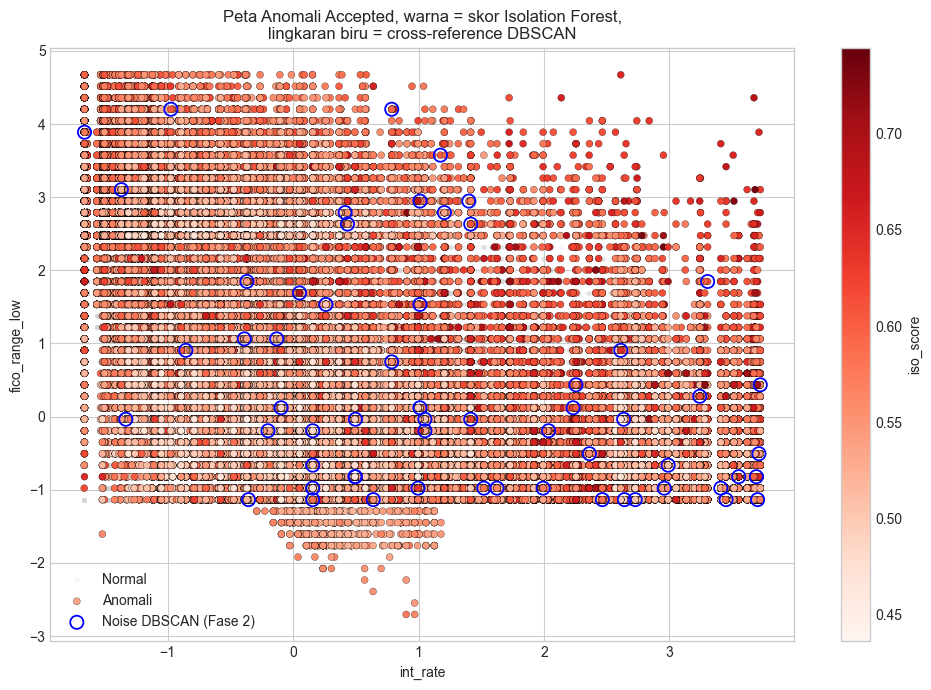

In [31]:
# Scatter anomali di ruang 2 fitur paling informatif (Accepted)
if len(num_acc) >= 2:
    f1, f2 = num_acc[0], num_acc[1]
    fig, ax = plt.subplots(figsize=(10, 7))
    normal = df_acc['anomaly_tier'] == 'Normal'
    ax.scatter(df_acc.loc[normal, f1], df_acc.loc[normal, f2],
               s=6, alpha=0.15, color='lightgray', label='Normal')
    anom = ~normal
    sc = ax.scatter(df_acc.loc[anom, f1], df_acc.loc[anom, f2],
                    s=25, c=df_acc.loc[anom, 'iso_score'], cmap='Reds',
                    edgecolor='k', linewidth=0.2, label='Anomali')
    # sorot yang juga noise DBSCAN
    db = df_acc['is_dbscan_noise']
    ax.scatter(df_acc.loc[db, f1], df_acc.loc[db, f2],
               s=90, facecolors='none', edgecolors='blue', linewidth=1.3,
               label='Noise DBSCAN (Fase 2)')
    ax.set_xlabel(f1); ax.set_ylabel(f2)
    ax.set_title('Peta Anomali Accepted, warna = skor Isolation Forest,\n'
                 'lingkaran biru = cross-reference DBSCAN')
    plt.colorbar(sc, label='iso_score')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.savefig('Results/anomaly_scatter_accepted.png', dpi=120, bbox_inches='tight')
    plt.show()

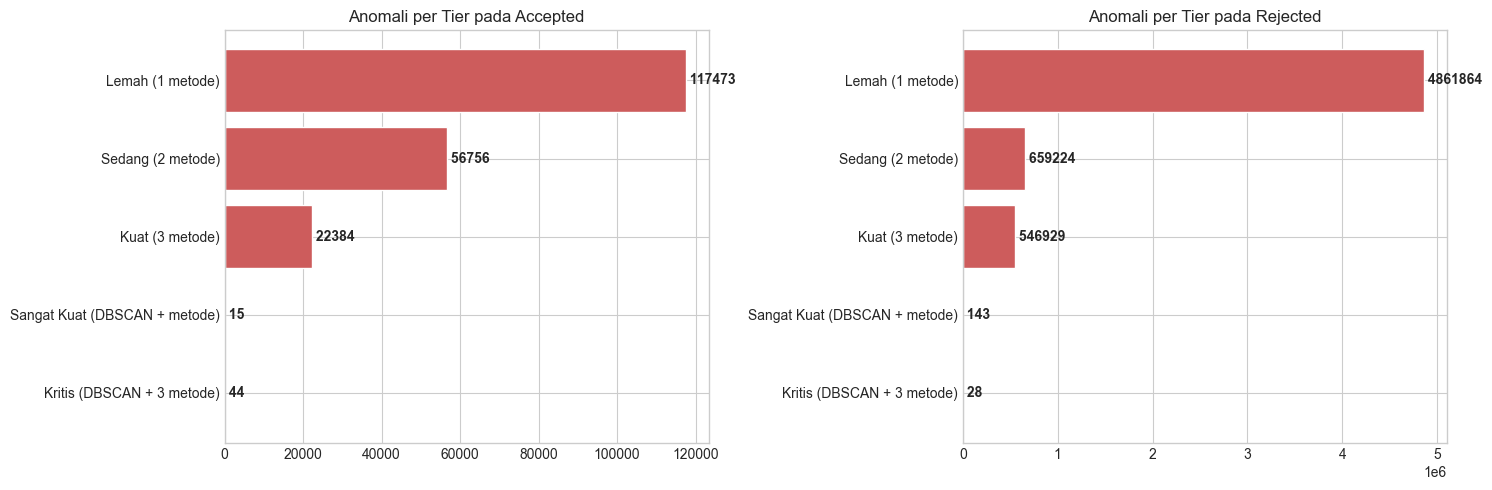

In [32]:
# Bar: jumlah anomali per tier (kedua dataset)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = ['Lemah (1 metode)','Sedang (2 metode)','Kuat (3 metode)',
         'Sangat Kuat (DBSCAN + metode)','Kritis (DBSCAN + 3 metode)']
for ax, df, ttl in [(axes[0], df_acc, 'Accepted'), (axes[1], df_rej, 'Rejected')]:
    vc = df['anomaly_tier'].value_counts().reindex(order).dropna()
    ax.barh(vc.index, vc.values, color='indianred', edgecolor='white')
    for i, v in enumerate(vc.values):
        ax.text(v, i, f' {int(v)}', va='center', fontweight='bold')
    ax.set_title(f'Anomali per Tier pada {ttl}')
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig('Results/anomaly_tiers.png', dpi=120, bbox_inches='tight')
plt.show()

Pemeriksaan tier Kritis memberi temuan yang konkret: seluruh 44 record accepted yang
disepakati keempat pendekatan (DBSCAN + IQR + Z-score + Isolation Forest) terklasifikasi
sebagai Sinyal Risiko, dan tidak ada satu pun yang tergolong kesalahan data. Fitur pemicu
yang paling sering ekstrem di antara mereka adalah jumlah akun yang dibuka baru-baru ini
(num_tl_op_past_12m, rata-rata |z| tertinggi), yaitu pola pembukaan akun yang agresif.
Pada peta sebaran, titik-titik ini muncul di wilayah skor Isolation Forest paling anomali.
Karena bukti statistik dan struktural bertemu di record yang sama, inilah kandidat eskalasi
paling kuat. Untuk rejected, 28 record Kritis-nya menandai pengajuan dengan atribut paling
ekstrem pada ketiga fiturnya.

# 11. Menyimpan Hasil (Laporan Anomali)

Saya menyimpan seluruh record anomali beserta penanda metode dan tingkat keyakinannya ke CSV,
lengkap dengan tabel investigasi yang memuat kolom verdict manual dan bukti. Berkas-berkas ini
saya siapkan agar bisa langsung dipakai sebagai panel dashboard di Fase 5.

In [33]:
# Simpan record anomali beserta flag & tier untuk dipakai Fase 5 (dashboard)
report_cols_acc = (num_acc + ['is_outlier_iqr','is_outlier_z','is_outlier_iso',
                   'is_dbscan_noise','n_methods_flag','iso_score','anomaly_tier',
                   'is_contextual_outlier','is_collective_outlier','cluster_label',
                   'year'])
report_cols_acc = [c for c in report_cols_acc if c in df_acc.columns]

anom_acc_out = df_acc[df_acc['anomaly_tier'] != 'Normal'][report_cols_acc].copy()

# Sertakan tipologi (auto_verdict) agar kartu "Komposisi tipologi anomali" di dashboard terisi.
# prio_acc berasal dari filter yang SAMA (anomaly_tier != 'Normal'), jadi indeksnya identik.
for _col in ['auto_verdict', 'auto_reasons']:
    if _col in prio_acc.columns:
        anom_acc_out[_col] = prio_acc[_col].reindex(anom_acc_out.index)

anom_acc_out.to_csv('Results/anomaly_report_accepted.csv', index=True)

report_cols_rej = (num_rej + ['is_outlier_iqr','is_outlier_z','is_outlier_iso',
                   'is_dbscan_noise','n_methods_flag','iso_score','anomaly_tier',
                   'year'])
report_cols_rej = [c for c in report_cols_rej if c in df_rej.columns]
anom_rej_out = df_rej[df_rej['anomaly_tier'] != 'Normal'][report_cols_rej]
anom_rej_out.to_csv('Results/anomaly_report_rejected.csv', index=True)

# Tabel investigasi (dengan kolom manual) untuk Accepted
prio_acc.to_csv('Results/investigation_table_accepted.csv', index=True)

print(f'Tersimpan:')
print(f'  anomaly_report_accepted.csv  -> {anom_acc_out.shape[0]:,} record')
print(f'  anomaly_report_rejected.csv  -> {anom_rej_out.shape[0]:,} record')
print(f'  investigation_table_accepted.csv (dengan kolom manual_verdict/evidence)')

Tersimpan:
  anomaly_report_accepted.csv  -> 196,672 record
  anomaly_report_rejected.csv  -> 6,068,188 record
  investigation_table_accepted.csv (dengan kolom manual_verdict/evidence)


# 12. Kesimpulan Fase 4

Melalui fase ini saya berhasil memisahkan record yang benar-benar menyimpang dari sekadar
variasi normal, dan yang lebih penting, menjelaskan makna tiap penyimpangan. Berikut ringkasan
yang saya rangkum:

1. Saya menerapkan tiga metode deteksi yang saling melengkapi (IQR dan Z-score yang univariat,
   serta Isolation Forest yang multivariat), lalu membandingkannya secara sistematis lewat
   skor konsensus, bukan menjalankannya terpisah-pisah.

2. Saya tidak berhenti pada global outlier. Saya melengkapinya dengan contextual outlier
   (bunga yang menyimpang relatif terhadap bucket FICO-nya, sehingga menangkap record yang
   lolos semua ambang global) dan collective outlier (klaster Highest-Risk Fase 2 yang
   menyimpang secara kolektif). Ketiga tipe ini memperlihatkan bahwa anomali yang paling
   penting bagi bank sering bukan nilai tunggal yang ekstrem, melainkan penyimpangan yang
   hanya muncul saat konteks atau kelompok diperhitungkan.

3. Saya menyilangkan temuan Fase 4 dengan noise DBSCAN dari Fase 2, lalu menyusun tingkat
   keyakinan berlapis. Lapisan tertinggi (tier Kritis) hanya berisi 44 record accepted dan
   28 rejected yang disepakati keempat pendekatan sekaligus; jumlah yang kecil ini saya
   interpretasi satu per satu sebagai bukti berlapis, bukan sekadar agregat.

4. Saya mengklasifikasikan tiap anomali prioritas ke dalam tiga tipologi (kesalahan data,
   kasus langka yang sah, atau sinyal risiko) dengan bukti angka yang ditarik langsung dari
   data, lalu menyimpannya untuk investigasi lanjutan.

Jawaban atas pertanyaan sentral, apa yang saya temukan yang tidak terlihat langsung dari data
mentah: saya menemukan bahwa anomali paling penting bukanlah nilai tunggal yang ekstrem,
melainkan record yang ditandai oleh banyak metode sekaligus dan sekaligus terisolasi dari
seluruh klaster. Titik-titik inilah, tempat bukti statistik dan bukti struktural bertemu, yang
paling layak dieskalasi sebagai kandidat kesalahan input atau sinyal risiko, dan itu tidak
akan terlihat hanya dengan menyaring satu kolom pada satu waktu.

Beberapa temuan konkret yang saya peroleh dari eksekusi, bukan dari dugaan awal:

- Ke-349 record yang semula tampak seperti kesalahan input (|z|>8 pada jumlah akun) ternyata
  BUKAN error setelah saya periksa nilai mentahnya dari Fase 1: jumlah akun tertinggi adalah
  64 dalam 24 bulan (median 30), ekstrem namun masih mungkin dilakukan manusia. Karena itu
  saya reklasifikasi seluruhnya menjadi sinyal risiko (pola loan-stacking), bukan noise yang
  dibuang. Ini menegaskan bahwa ambang statistik saja tidak cukup; verifikasi nilai asli
  mengubah kesimpulan.
- Irisan antara collective outlier (anggota klaster Highest-Risk) dan global outlier (>=2
  metode) berjumlah 42.440 record dengan default rate 36,5%, lebih tinggi dari rata-rata
  segmen Highest-Risk (33,4%) maupun populasi total (20,0%). Artinya menyimpang di dua level
  sekaligus, segmen dan individu, memang menandakan risiko lebih besar, dan sub-populasi
  inilah prioritas eskalasi tertinggi.
- Seluruh 44 record tier Kritis accepted terklasifikasi sinyal risiko (tidak ada kesalahan
  data), dengan pemicu paling sering berupa pembukaan akun yang agresif. Konvergensi empat
  metode di record yang sama memberi keyakinan tertinggi bahwa ini pola risiko nyata.

Untuk Mining Expo, temuan yang saya angkat: teknik deteksi anomali bersifat domain-agnostic,
tetapi makna anomali dibentuk oleh konteks. Pada accepted, anomali cenderung berbicara tentang
kombinasi risiko gagal bayar; pada rejected yang atributnya terbatas, anomali lebih banyak
menggambarkan pengajuan ekstrem yang wajar ditolak. Semua hasil saya simpan sebagai laporan
anomali dan gambar untuk dashboard Fase 5.

In [34]:
print('='*70)
print('RINGKASAN FASE 4: ANOMALY & OUTLIER DETECTION')
print('='*70)
for df, nm in [(df_acc,'ACCEPTED'), (df_rej,'REJECTED')]:
    print(f'\n[{nm}]')
    print(f"  Total record            : {len(df):,}")
    print(f"  Anomali IQR             : {df['is_outlier_iqr'].sum():,}")
    print(f"  Anomali Z-score         : {df['is_outlier_z'].sum():,}")
    print(f"  Anomali Isolation Forest: {df['is_outlier_iso'].sum():,}")
    print(f"  Noise DBSCAN (Fase 2)   : {df['is_dbscan_noise'].sum():,}")
    print(f"  Cross-ref (DBSCAN+>=1)  : {(df['is_dbscan_noise'] & (df['n_methods_flag']>=1)).sum():,}")
    if nm=='ACCEPTED':
        print(f"  Contextual outlier      : {int(df.get('is_contextual_outlier', pd.Series(False)).sum()):,}")
        print(f"  Collective (zona risiko): {int(df.get('in_collective_zone', pd.Series(False)).sum()):,}")
        if 'cluster_label' in df.columns:
            print(f"  Anggota Highest-Risk    : {int((df['is_collective_outlier']).sum()):,} (klaster eksak)")
    print(f"  Tier Kritis             : {(df['anomaly_tier']=='Kritis (DBSCAN + 3 metode)').sum():,}")
print('\n' + '='*70)

RINGKASAN FASE 4: ANOMALY & OUTLIER DETECTION

[ACCEPTED]
  Total record            : 1,348,099
  Anomali IQR             : 196,261
  Anomali Z-score         : 75,071
  Anomali Isolation Forest: 26,962
  Noise DBSCAN (Fase 2)   : 59
  Cross-ref (DBSCAN+>=1)  : 59
  Contextual outlier      : 14,385
  Collective (zona risiko): 347,489
  Anggota Highest-Risk    : 347,489 (klaster eksak)
  Tier Kritis             : 44

[REJECTED]
  Total record            : 27,490,787
  Anomali IQR             : 6,068,188
  Anomali Z-score         : 1,203,457
  Anomali Isolation Forest: 549,744
  Noise DBSCAN (Fase 2)   : 171
  Cross-ref (DBSCAN+>=1)  : 171
  Tier Kritis             : 28



---

## Pola Bisnis dalam Bahasa Sederhana

Bagian ini menerjemahkan temuan menjadi kalimat yang bisa dipahami tanpa latar belakang
statistik. Sel berikut menghitung empat pola langsung dari data; angka-angkanya kemudian saya
rangkum menjadi cerita di bawahnya. Saya memakai diksi yang menyesuaikan kekuatan pola,
yaitu cenderung dan bukan selalu atau pasti, karena hampir tak ada pola perbankan yang
berlaku 100% tanpa pengecualian. Pengecualian itu sendiri sering menjadi hal yang paling
menarik untuk ditinjau.

In [35]:
# --- Menghitung pola bisnis untuk narasi (semua angka berasal dari data, bukan diketik manual) ---
# Fitur ter-z-score: nilai < 0 = di bawah rata-rata, > 0 = di atas rata-rata.
biz = {}

# Pola 1: apakah nasabah FICO rendah CENDERUNG dapat bunga tinggi?
# 'FICO rendah' = 20% terbawah; lihat berapa % dari mereka yang bunganya di atas median.
fico_low_cut = df_acc['fico_range_low'].quantile(0.20)
int_med = df_acc['int_rate'].median()
low_fico = df_acc[df_acc['fico_range_low'] <= fico_low_cut]
biz['p1_pct_lowfico_highrate'] = (low_fico['int_rate'] > int_med).mean() * 100
biz['p1_avg_rate_lowfico_z'] = low_fico['int_rate'].mean()
# pembanding: FICO tinggi (20% teratas)
fico_high_cut = df_acc['fico_range_low'].quantile(0.80)
high_fico = df_acc[df_acc['fico_range_low'] >= fico_high_cut]
biz['p1_pct_highfico_highrate'] = (high_fico['int_rate'] > int_med).mean() * 100

# Pola 2: apakah bunga tinggi CENDERUNG diikuti default lebih tinggi?
if 'loan_status_binary' in df_acc.columns:
    rate_hi = df_acc[df_acc['int_rate'] > df_acc['int_rate'].quantile(0.80)]
    rate_lo = df_acc[df_acc['int_rate'] < df_acc['int_rate'].quantile(0.20)]
    biz['p2_default_highrate'] = rate_hi['loan_status_binary'].mean() * 100
    biz['p2_default_lowrate']  = rate_lo['loan_status_binary'].mean() * 100

# Pola 3: klaster Highest-Risk vs Prime, default rate (dari collective outlier)
if 'loan_status_binary' in df_acc.columns and 'is_collective_outlier' in df_acc.columns:
    biz['p3_default_highrisk'] = df_acc[df_acc['is_collective_outlier']]['loan_status_binary'].mean()*100
    biz['p3_default_rest']     = df_acc[~df_acc['is_collective_outlier']]['loan_status_binary'].mean()*100

# Pola 4: nasabah yang banyak buka akun (loan-stacking) cenderung default lebih tinggi?
if 'num_tl_op_past_12m' in df_acc.columns and 'loan_status_binary' in df_acc.columns:
    stack_hi = df_acc[df_acc['num_tl_op_past_12m'] > df_acc['num_tl_op_past_12m'].quantile(0.90)]
    biz['p4_default_stack']   = stack_hi['loan_status_binary'].mean()*100
    biz['p4_default_overall'] = df_acc['loan_status_binary'].mean()*100

# Cetak ringkas
print('POLA 1, FICO rendah vs bunga:')
print(f"  Dari nasabah FICO terendah (20% bawah), {biz['p1_pct_lowfico_highrate']:.1f}% menerima bunga di atas median.")
print(f"  Bandingkan: dari nasabah FICO tertinggi, hanya {biz['p1_pct_highfico_highrate']:.1f}% yang bunganya di atas median.")
if 'p2_default_highrate' in biz:
    print('\nPOLA 2, Bunga vs gagal bayar:')
    print(f"  Bunga tertinggi (20% atas): default {biz['p2_default_highrate']:.1f}%")
    print(f"  Bunga terendah (20% bawah): default {biz['p2_default_lowrate']:.1f}%")
if 'p3_default_highrisk' in biz:
    print('\nPOLA 3, Segmen Highest-Risk vs sisanya:')
    print(f"  Klaster Highest-Risk: default {biz['p3_default_highrisk']:.1f}%")
    print(f"  Nasabah lainnya     : default {biz['p3_default_rest']:.1f}%")
if 'p4_default_stack' in biz:
    print('\nPOLA 4, Banyak buka akun (loan-stacking) vs gagal bayar:')
    print(f"  Buka akun terbanyak (10% atas): default {biz['p4_default_stack']:.1f}%")
    print(f"  Rata-rata seluruh populasi     : default {biz['p4_default_overall']:.1f}%")

POLA 1, FICO rendah vs bunga:
  Dari nasabah FICO terendah (20% bawah), 67.4% menerima bunga di atas median.
  Bandingkan: dari nasabah FICO tertinggi, hanya 21.4% yang bunganya di atas median.

POLA 2, Bunga vs gagal bayar:
  Bunga tertinggi (20% atas): default 35.9%
  Bunga terendah (20% bawah): default 6.7%

POLA 3, Segmen Highest-Risk vs sisanya:
  Klaster Highest-Risk: default 33.4%
  Nasabah lainnya     : default 15.3%

POLA 4, Banyak buka akun (loan-stacking) vs gagal bayar:
  Buka akun terbanyak (10% atas): default 27.0%
  Rata-rata seluruh populasi     : default 20.0%


### Cerita di Balik Angka

1. Nasabah dengan skor kredit (FICO) rendah cenderung menerima bunga tinggi, tetapi ini bukan
hukum mutlak. Dari kelompok FICO terendah, 67% mendapat bunga di atas median, sementara pada
kelompok FICO tertinggi angkanya hanya 21%. Bunga jelas mengikuti risiko: makin rendah skor
kredit, makin besar peluang dikenai bunga tinggi. Namun sepertiga nasabah FICO rendah justru
tetap memperoleh bunga rendah, dan pengecualian inilah yang menarik untuk ditinjau, karena bisa
menandakan penetapan harga yang longgar atau faktor lain di luar skor kredit.

2. Pinjaman berbunga tinggi lebih sering gagal bayar. Kelompok bunga tertinggi gagal bayar
35,9%, lebih dari lima kali lipat kelompok bunga terendah yang hanya 6,7%. Bunga tinggi adalah
harga yang bank kenakan atas risiko, dan data membenarkan bahwa risiko itu memang nyata, bukan
sekadar asumsi.

3. Segmen Highest-Risk dari Fase 2 memang paling banyak gagal bayar. Default-nya 33,4%,
lebih dari dua kali lipat 15,3% pada nasabah lainnya. Ini memvalidasi bahwa klaster hasil
Fase 2 bukan sekadar pengelompokan matematis, melainkan benar-benar memisahkan tingkat risiko
yang berbeda di dunia nyata.

4. Nasabah yang membuka banyak akun sekaligus lebih berisiko. Kelompok pembuka akun
terbanyak (10% teratas) gagal bayar 27,0%, di atas rata-rata populasi 20,0%. Inilah pola
loan-stacking yang sempat dikira kesalahan data pada tahap klasifikasi awal, padahal setelah
diverifikasi merupakan sinyal risiko yang nyata. Nasabah yang agresif membuka kredit baru
memang cenderung lebih rapuh secara finansial.

Benang merahnya: keempat pola ini masuk akal secara perbankan dan saling menguatkan, tetapi
tak satu pun berlaku 100%. Justru pengecualian di tiap pola, seperti nasabah FICO rendah
berbunga rendah atau pinjaman bunga rendah yang tetap gagal bayar, yang paling layak menjadi
bahan investigasi lanjutan.

---

## Insight Fase 4: Apa yang Sebenarnya Kami Pelajari

Kalau seluruh fase ini diringkas menjadi satu pelajaran, pelajaran itu adalah bahwa anomali yang
penting bagi bank jarang berupa satu angka yang mencolok, dan menemukannya menuntut lebih dari
sekadar menyaring kolom. Empat hal di bawah ini adalah inti yang saya bawa keluar dari Fase 4.

Pertama, metode yang berbeda menangkap anomali yang berbeda, dan justru pertemuannya yang
bermakna. IQR menandai 13% populasi, Isolation Forest hanya 2%; keduanya tidak salah, mereka
sekadar memandang dari sudut berbeda. Yang paling bisa saya percayai bukan record yang ditandai
satu metode, melainkan yang disepakati banyak metode sekaligus. Ketika saya tambahkan
DBSCAN dari Fase 2, lapisan tertinggi menyusut menjadi hanya 44 record accepted. Kelangkaan
itulah yang membuatnya berharga: sedikit, tetapi hampir pasti nyata.

Kedua, ambang statistik bisa menyesatkan tanpa verifikasi nilai asli. Klasifikasi awal saya
menuduh 349 record sebagai kesalahan input hanya karena |z|-nya sangat besar. Setelah saya
kembalikan ke jumlah akun mentahnya, ternyata angka tertinggi pun (64 akun dalam 24 bulan)
masih dalam batas yang mungkin dilakukan manusia. Semua 349 bukan error, melainkan perilaku
pembukaan akun yang agresif, sebuah sinyal risiko dan bukan noise. Tanpa langkah verifikasi ini,
saya akan membuang justru sinyal yang seharusnya saya perhatikan.

Ketiga, risiko terbesar sering bersifat kolektif, bukan individual. Collective outlier
mencakup seluruh klaster Highest-Risk (sekitar 26% populasi), cakupan yang besar karena
mengukur risiko pada level segmen. Tetapi ketika saya iriskan dengan penyimpangan individual,
42.440 record yang menyimpang di dua level sekaligus menunjukkan default rate 36,5%, lebih
tinggi dari segmennya sendiri maupun populasi. Inilah bukti kuantitatif bahwa anggota segmen
berisiko yang juga menonjol secara pribadi adalah kelompok yang paling layak dieskalasi.

Keempat, makna anomali dibentuk oleh konteks dataset. Pada accepted, anomali berbicara
tentang kombinasi risiko gagal bayar yang bisa saya validasi terhadap `loan_status`. Pada
rejected yang atributnya jauh lebih terbatas, anomali lebih menggambarkan pengajuan ekstrem
yang wajar ditolak, dan saya tidak memaksakan interpretasi risiko yang tidak didukung datanya.
Teknik deteksinya identik; artinya yang berbeda. Itulah yang membuat langkah interpretasi tidak
tergantikan oleh algoritma mana pun.